# Baseline & Agentic RAG Exploratory Data Analysis

Covers all three evaluation datasets:
- `agentic_rag_20 comparison questions.csv` - 20 agentic queries with full metadata
- `baseline_rag_20 comparison questions.csv` - 20 baseline queries (same questions)
- `agentic_rag_55 questions.csv` - 55-question full agentic evaluation

**Sections**
1. Query-Type & Scope Distribution
2. Response Time Analysis
3. Cost & Token Analysis
4. Confidence Analysis
5. Correlation Heatmaps
6. Per-Query Cost, Latency & Confidence Profiles

In [ ]:
import re
import csv
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.transforms as transforms
from matplotlib.patches import Ellipse


EVALS_DIR    = Path(".")
DATASETS_DIR = EVALS_DIR / "datasets"

OOS_MARKER = "outside the German timber market scope"

COLORS     = ["#2563EB", "#10B981", "#7C3AED", "#F97316"]
AGT_COLOR  = "#2563EB"
BASE_COLOR = "#F97316"
TYPE_COLORS = {"simple": "#2563EB", "temporal": "#10B981",
               "multi_hop": "#7C3AED", "comparison": "#F97316",
               "requires_live_search": "#F59E0B"}

plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "#F8F9FA",
    "axes.edgecolor":     "#D1D5DB",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.titlesize":     13,
    "axes.titleweight":   "bold",
    "axes.titlepad":      12,
    "axes.labelsize":     11,
    "axes.labelcolor":    "#374151",
    "axes.axisbelow":     True,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "xtick.color":        "#6B7280",
    "ytick.color":        "#6B7280",
    "xtick.bottom":       False,
    "ytick.left":         False,
    "grid.color":         "#E5E7EB",
    "grid.linewidth":     0.75,
    "grid.linestyle":     "--",
    "legend.fontsize":    10,
    "legend.framealpha":  0.95,
    "legend.edgecolor":   "#E5E7EB",
    "figure.dpi":         130,
    "savefig.bbox":       "tight",
})

def _style(ax, ylabel=None, ylim=None):
    ax.spines["left"].set_color("#D1D5DB")
    ax.spines["bottom"].set_color("#D1D5DB")
    ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)
    if ylabel: ax.set_ylabel(ylabel, labelpad=8)
    if ylim:   ax.set_ylim(*ylim)

# Load datasets
agt20 = pd.read_csv(DATASETS_DIR / "agentic_rag_20 comparison questions.csv", encoding="utf-8-sig")
bas20 = pd.read_csv(DATASETS_DIR / "baseline_rag_20 comparison questions.csv", encoding="latin-1")
agt55 = pd.read_csv(DATASETS_DIR / "agentic_rag_55 questions.csv", encoding="utf-8-sig")

for df in [agt20, bas20, agt55]:
    df.columns = [c.lstrip("\ufeff").strip() for c in df.columns]
    df.rename(columns={c: "No." for c in df.columns if c.endswith("No.")}, inplace=True)

def _parse_conf(s):
    s = str(s).strip()
    if "%" in s:
        return float(s.replace("%", "")) / 100
    try:    return float(s)
    except: return np.nan

for df in [agt20, bas20, agt55]:
    df["confidence"] = df["Confidence / Avg Similarity"].apply(_parse_conf)
    for col in ["Cost ($)", "Tokens", "LLM Calls", "Resp. Time (s)"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df["query_len"]    = df["Query"].str.split().str.len()
    df["response_len"] = df["Response"].str.split().str.len()
    ctx_cols = [c for c in df.columns if re.match(r"context_\d+", c)]
    df["ctx_count"] = df[ctx_cols].apply(
        lambda r: r.fillna("").astype(str).str.strip().ne("").sum(), axis=1)

# Scope labelling for 55q
agt55["scope"] = agt55.apply(
    lambda row: "OOS" if OOS_MARKER in str(row["ground_truth"]) else (
                "Live" if row["query_type"] == "requires_live_search" else "In-scope"), axis=1)

agt55_in = agt55[agt55["scope"] == "In-scope"].copy()

print(f"agt20 : {agt20.shape}")
print(f"bas20 : {bas20.shape}")
print(f"agt55 : {agt55.shape}")
print(f"  scope breakdown: { dict(agt55['scope'].value_counts()) }")
print(f"  in-scope rows  : {len(agt55_in)}")
print("Setup complete.")


agt20 : (20, 25)
bas20 : (20, 21)
agt55 : (55, 30)
  scope breakdown: {'In-scope': np.int64(41), 'Live': np.int64(8), 'OOS': np.int64(6)}
  in-scope rows  : 41
Setup complete.


## 1. Query-Type & Scope Distribution

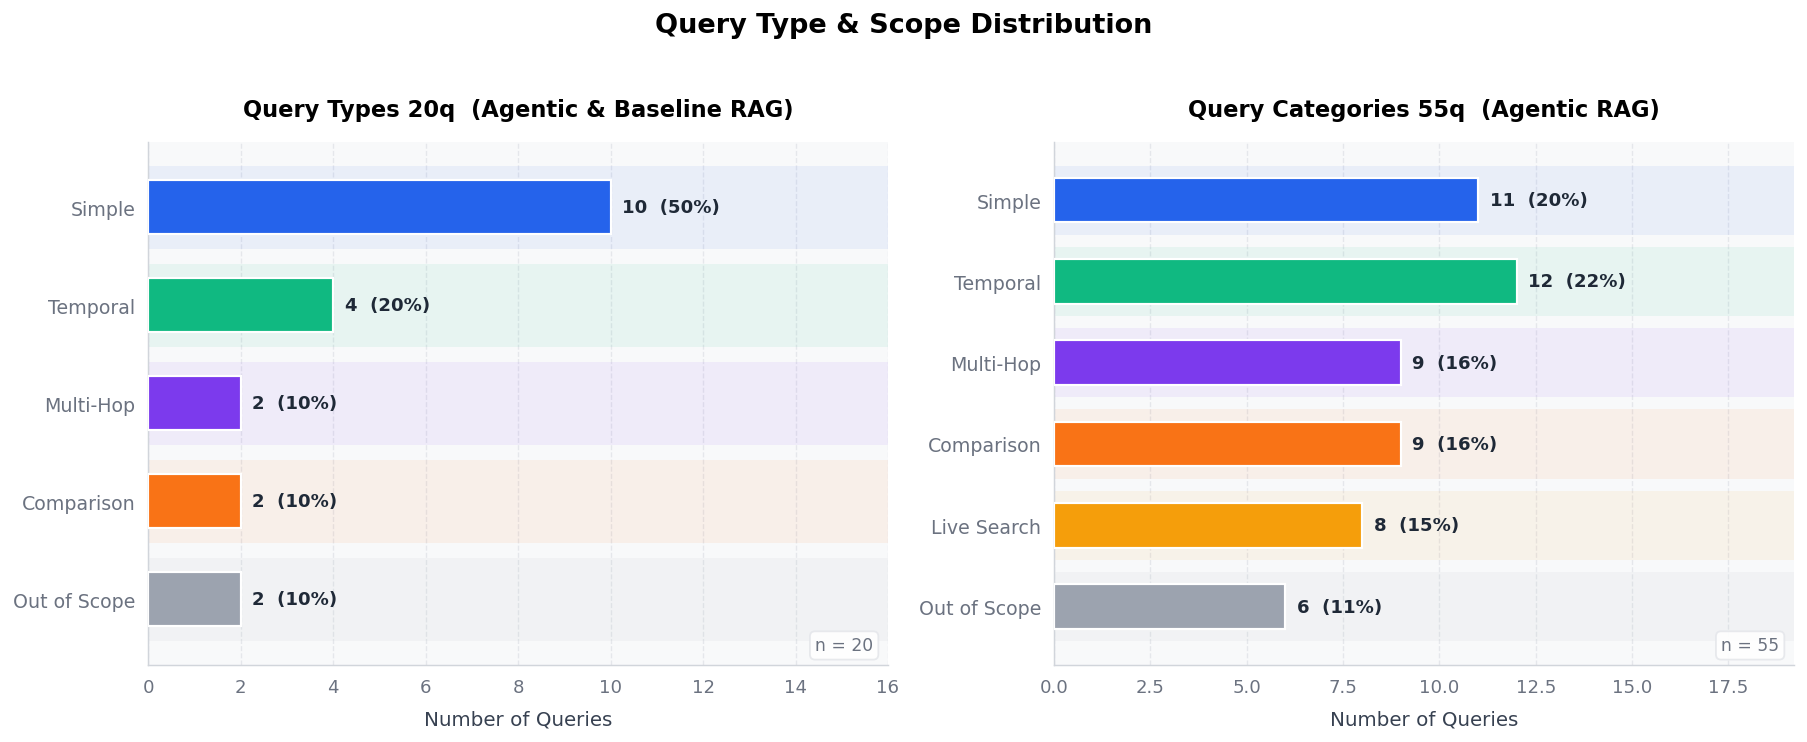

20q query types: {'Simple': np.int64(10), 'Temporal': np.int64(4), 'Multi-Hop': np.int64(2), 'Comparison': np.int64(2), 'Out of Scope': np.int64(2)}
55q breakdown  : {'Simple': np.int64(11), 'Temporal': np.int64(12), 'Multi-Hop': np.int64(9), 'Comparison': np.int64(9), 'Live Search': 8, 'Out of Scope': 6}


In [182]:
# 20q: include all query_type values
all_types_20  = agt20["query_type"].value_counts()
cat_order_20  = ["simple", "temporal", "multi_hop", "comparison", "Out_of_Scope"]
counts_20     = all_types_20.reindex(cat_order_20).fillna(0).astype(int)
colors_20     = ["#2563EB", "#10B981", "#7C3AED", "#F97316", "#9CA3AF"]
labels_20     = ["Simple", "Temporal", "Multi-Hop", "Comparison", "Out of Scope"]

# 55q categories
type_counts_55 = agt55_in["query_type"].value_counts().reindex(
    ["simple", "temporal", "multi_hop", "comparison"]).fillna(0).astype(int)
live_count = int((agt55["scope"] == "Live").sum())
oos_count  = int((agt55["scope"] == "OOS").sum())

cat_labels_55 = ["Simple", "Temporal", "Multi-Hop", "Comparison", "Live Search", "Out of Scope"]
all_vals_55   = list(type_counts_55.values) + [live_count, oos_count]
cat_colors_60 = ["#2563EB", "#10B981", "#7C3AED", "#F97316", "#F59E0B", "#9CA3AF"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, (labels, values, colors, title, total) in zip(axes, [
    (labels_20, list(counts_20.values), colors_20,
     "Query Types 20q  (Agentic & Baseline RAG)", int(sum(counts_20.values))),
    (cat_labels_55, all_vals_55, cat_colors_60,
     "Query Categories 55q  (Agentic RAG)", int(sum(all_vals_55))),
]):
    max_v = max(values)
    # subtle background strips
    for j, (val, col) in enumerate(zip(values, colors)):
        ax.barh(j, max_v * 1.6, left=0, height=0.85, color=col, alpha=0.07, zorder=1)

    bars = ax.barh(range(len(labels)), values, color=colors,
                   edgecolor="white", linewidth=1.2, zorder=3, height=0.55)

    for bar, val in zip(bars, values):
        ax.text(val + max_v * 0.025, bar.get_y() + bar.get_height() / 2,
                f"{val}  ({val / total * 100:.0f}%)",
                va="center", ha="left", fontsize=10, fontweight="600", color="#1F2937")

    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=10.5)
    ax.set_xlim(0, max_v * 1.6)
    ax.set_title(title, fontsize=12.5, fontweight="bold", pad=14)
    ax.set_xlabel("Number of Queries", labelpad=8)
    ax.xaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)
    ax.yaxis.grid(False)
    ax.spines["left"].set_color("#D1D5DB");  ax.spines["bottom"].set_color("#D1D5DB")
    ax.spines["top"].set_visible(False);     ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True);  ax.set_facecolor("#F8F9FA")
    ax.invert_yaxis()
    ax.text(0.98, 0.02, f"n = {total}", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=9.5, color="#6B7280",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#E5E7EB", alpha=0.9))

fig.suptitle("Query Type & Scope Distribution", fontsize=15, fontweight="bold", y=1.03)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

print("20q query types:", dict(zip(labels_20, counts_20.values)))
print("55q breakdown  :", dict(zip(cat_labels_55, all_vals_55)))


>
> The 20-question comparison dataset covers five query types: Simple (10), Temporal (4), Multi-Hop (2), Comparison (2), and Out-of-Scope (2). The 2 out-of-scope questions were excluded from RAGAS evaluation but included here to verify scope-detection accuracy. The 55-question full dataset expands coverage to all five types with 41 in-scope questions (Simple 11, Temporal 12, Multi-Hop 9, Comparison 9) plus 8 *requires_live_search* and 6 out-of-scope queries. The distribution reflects a deliberate emphasis on temporal and simple queries, which dominate real-world news-based retrieval use cases in the German timber market domain.

## 2. Response Time Analysis

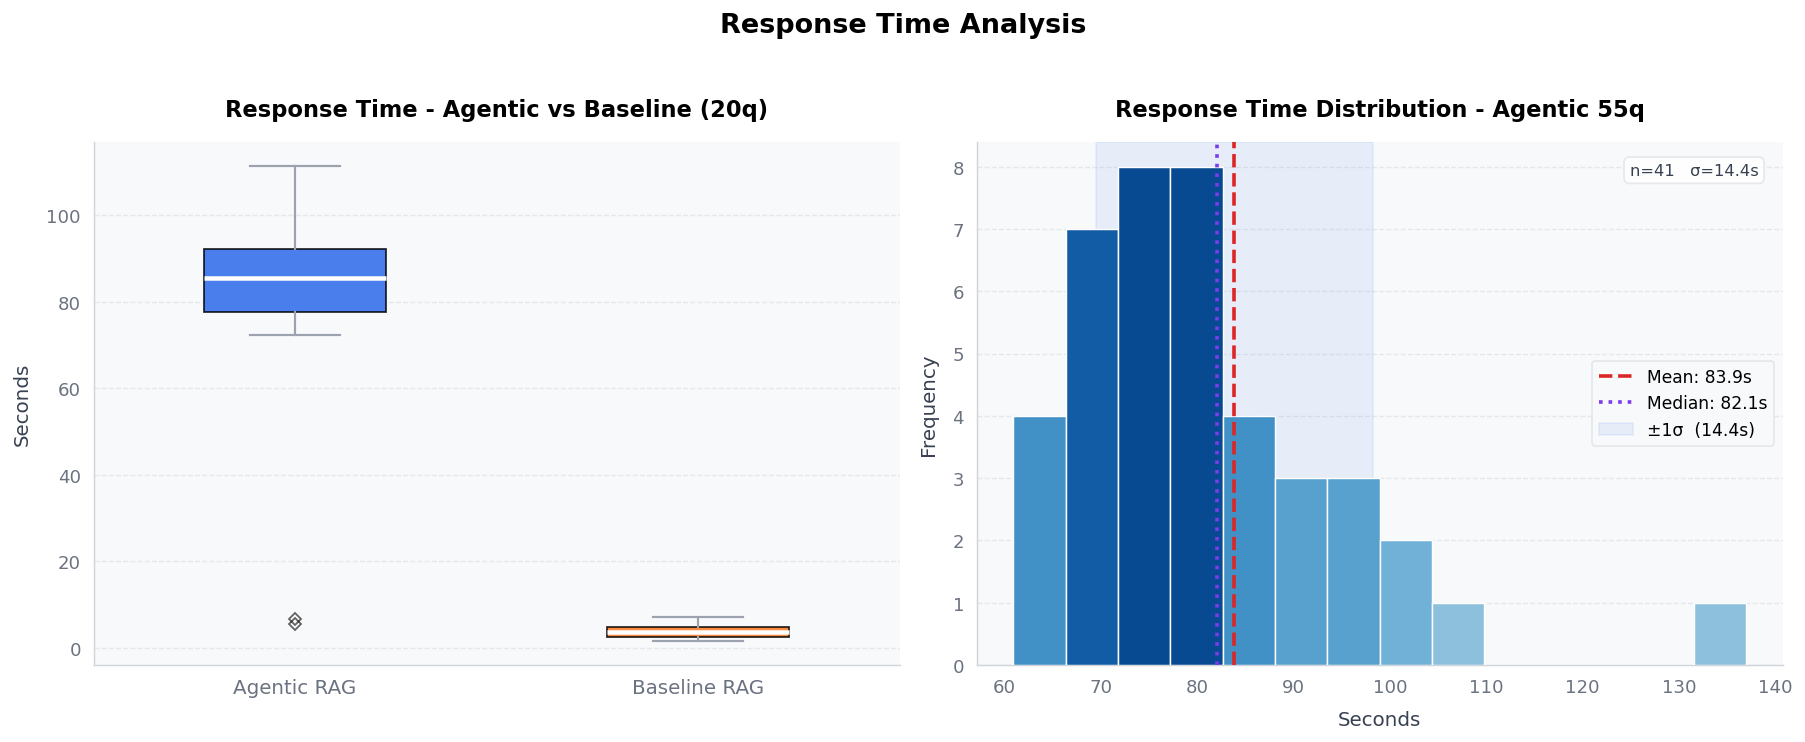

Agentic 20q  mean: 79.7s   median: 85.5s
Baseline 20q mean: 3.8s   median: 3.6s
Agentic 55q  mean: 83.9s


In [183]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: clean box plot - Agentic vs Baseline 20q 
ax = axes[0]
agt_rt = agt20["Resp. Time (s)"].dropna().values
bas_rt = bas20["Resp. Time (s)"].dropna().values

bp = ax.boxplot([agt_rt, bas_rt], positions=[1, 2], widths=0.45, patch_artist=True,
                medianprops=dict(color="white", linewidth=2.5),
                whiskerprops=dict(color="#9CA3AF", linewidth=1.2),
                capprops=dict(color="#9CA3AF", linewidth=1.2),
                flierprops=dict(marker="D", color="#9CA3AF", markersize=5, alpha=0.6))
for patch, color in zip(bp["boxes"], [AGT_COLOR, BASE_COLOR]):
    patch.set_facecolor(color); patch.set_alpha(0.82)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Agentic RAG", "Baseline RAG"], fontsize=11)
ax.set_title("Response Time - Agentic vs Baseline (20q)", fontsize=12.5, fontweight="bold", pad=14)
ax.set_ylabel("Seconds", labelpad=8)
ax.yaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)
ax.set_axisbelow(True); ax.set_facecolor("#F8F9FA")
ax.spines["top"].set_visible(False);    ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D1D5DB"); ax.spines["bottom"].set_color("#D1D5DB")

# Right: gradient histogram + stats - Agentic 55q 
ax = axes[1]
rt_data  = agt55_in["Resp. Time (s)"].dropna()
n_bins   = 14
counts_h, edges = np.histogram(rt_data, bins=n_bins)
cmap_b   = plt.cm.Blues
norm_v   = counts_h / counts_h.max()
for j in range(n_bins):
    ax.bar(edges[j], counts_h[j], width=edges[j+1] - edges[j],
           color=cmap_b(0.35 + 0.55 * norm_v[j]),
           edgecolor="white", linewidth=0.8, zorder=3)

mean_v   = rt_data.mean()
median_v = rt_data.median()
std_v    = rt_data.std()
ax.axvline(mean_v,   color="#DC2626", linestyle="--", linewidth=2.0, zorder=4,
           label=f"Mean: {mean_v:.1f}s")
ax.axvline(median_v, color="#7C3AED", linestyle=":",  linewidth=2.0, zorder=4,
           label=f"Median: {median_v:.1f}s")
ax.axvspan(mean_v - std_v, mean_v + std_v, alpha=0.08, color="#2563EB", zorder=1,
           label=f"±1σ  ({std_v:.1f}s)")

ax.set_title("Response Time Distribution - Agentic 55q", fontsize=12.5, fontweight="bold", pad=14)
ax.set_xlabel("Seconds", labelpad=8)
ax.set_ylabel("Frequency", labelpad=8)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#E5E7EB", fontsize=9.5)
_style(ax); ax.set_facecolor("#F8F9FA")
ax.text(0.97, 0.96, f"n={len(rt_data)}   σ={std_v:.1f}s",
        transform=ax.transAxes, ha="right", va="top", fontsize=9, color="#374151",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#E5E7EB", alpha=0.9))

fig.suptitle("Response Time Analysis", fontsize=15, fontweight="bold", y=1.03)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

print(f"Agentic 20q  mean: {agt20['Resp. Time (s)'].mean():.1f}s   median: {np.median(agt_rt):.1f}s")
print(f"Baseline 20q mean: {bas20['Resp. Time (s)'].mean():.1f}s   median: {np.median(bas_rt):.1f}s")
print(f"Agentic 55q  mean: {agt55_in['Resp. Time (s)'].mean():.1f}s")


>
> Response time is the most visible operational cost of the agentic pipeline. The agentic system averages **79.7 s** per query (median 85.5 s) vs **3.8 s** for the baseline, a ~21x latency increase. The agentic distribution is right-skewed, with a long tail driven by multi-hop and requires_live_search queries that trigger more retrieval iterations. The baseline distribution is tightly clustered near 3-5 s, reflecting a single-pass retrieval with no planning overhead. 

## 3. Cost & Token Analysis

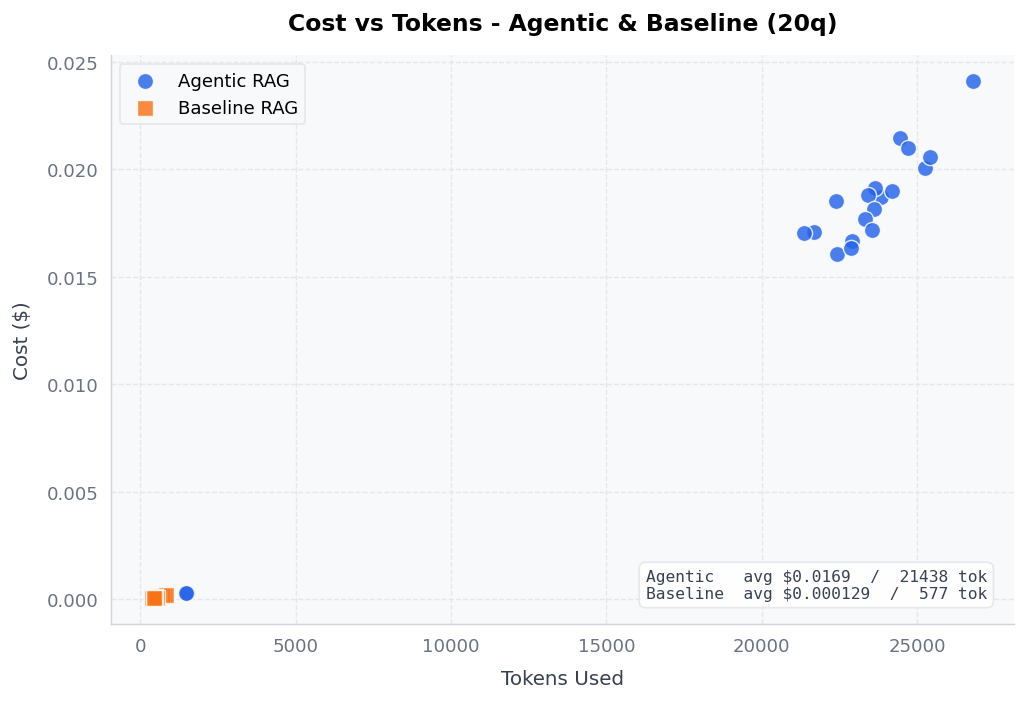

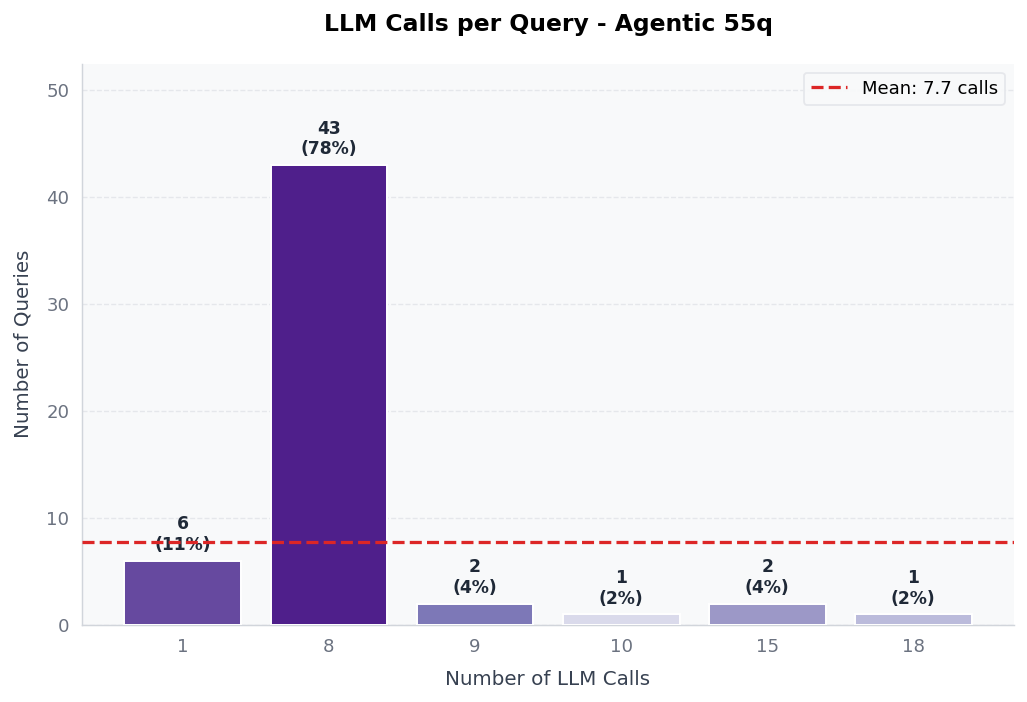

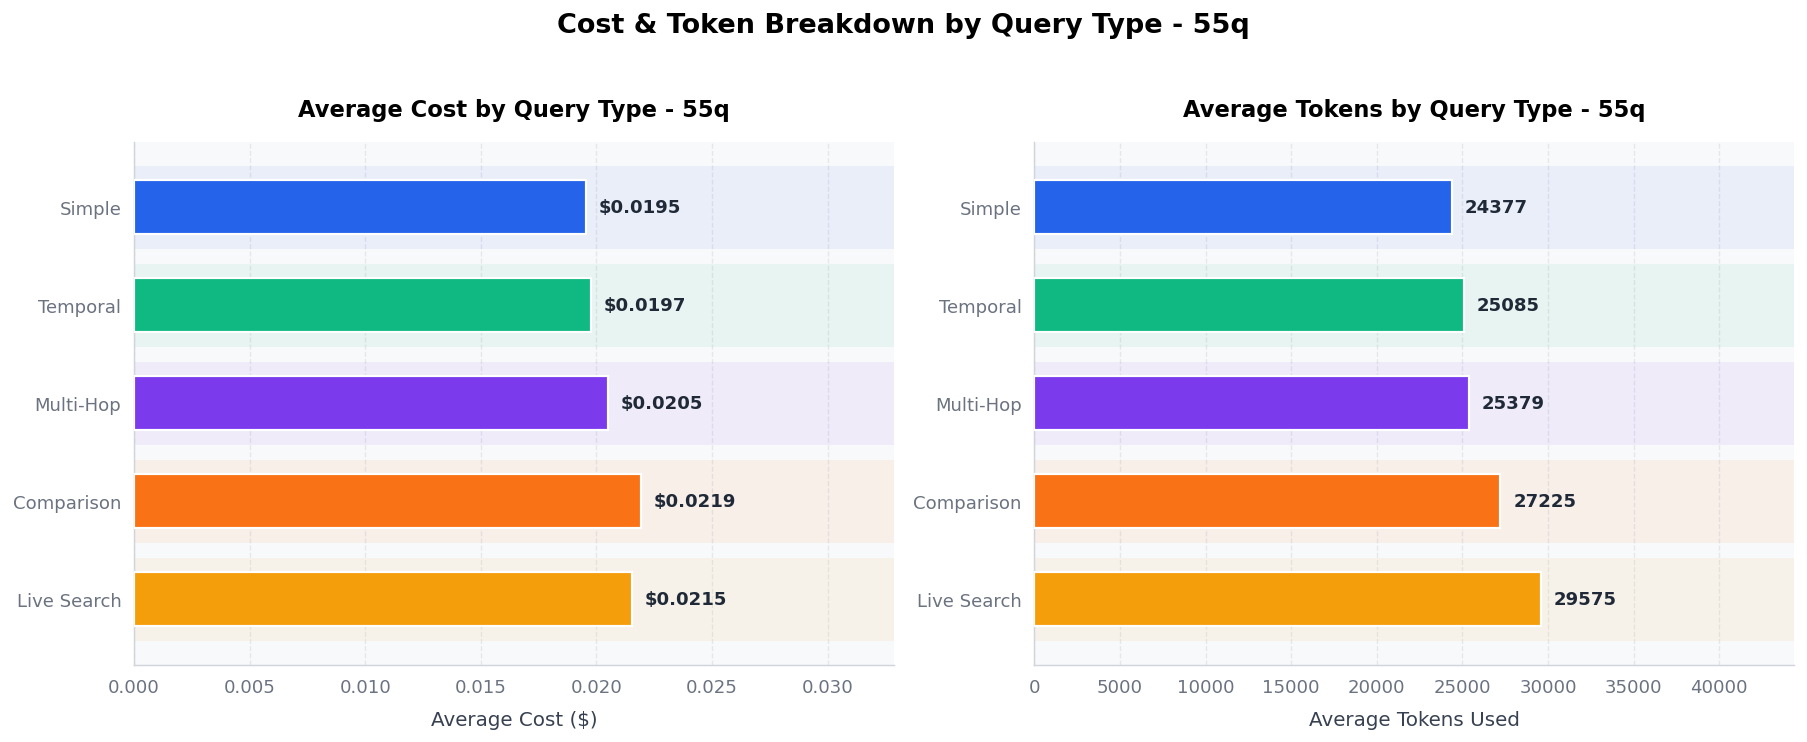

Agentic 20q  avg cost: $0.0169  avg tokens: 21438  avg LLM calls: 7.3
Baseline 20q avg cost: $0.000129  avg tokens: 577  avg LLM calls: 1.0

LLM calls distribution (all 55q):
LLM Calls
1      6
8     43
9      2
10     1
15     2
18     1
Name: count, dtype: int64


In [184]:

# Figure 1 - Cost vs Tokens  (Agentic & Baseline 20q)
fig, ax = plt.subplots(figsize=(8, 5.5))

for data, color, label, marker in [
    (agt20, AGT_COLOR,  "Agentic RAG",  "o"),
    (bas20, BASE_COLOR, "Baseline RAG", "s"),
]:
    ax.scatter(data["Tokens"], data["Cost ($)"],
               color=color, alpha=0.82, s=80, marker=marker,
               edgecolors="white", linewidths=0.8, label=label, zorder=3)

ax.set_title("Cost vs Tokens - Agentic & Baseline (20q)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Tokens Used", labelpad=8)
ax.set_ylabel("Cost ($)", labelpad=8)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#E5E7EB", fontsize=10)
_style(ax); ax.set_facecolor("#F8F9FA")
ax.xaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)

stats_box = (
    f"Agentic   avg ${agt20['Cost ($)'].mean():.4f}  /  {agt20['Tokens'].mean():.0f} tok\n"
    f"Baseline  avg ${bas20['Cost ($)'].mean():.6f}  /  {bas20['Tokens'].mean():.0f} tok"
)
ax.text(0.97, 0.04, stats_box, transform=ax.transAxes, ha="right", va="bottom",
        fontsize=9, color="#374151", family="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#E5E7EB", alpha=0.92))

fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

# Figure 2 - LLM Calls per Query  (Agentic 55q - all queries)
fig, ax = plt.subplots(figsize=(8, 5.5))

llm_counts = agt55["LLM Calls"].value_counts().sort_index()
n_bars     = len(llm_counts)
total_q    = len(agt55)
cmap_p     = plt.cm.Purples

# color by rank: highest bar = darkest, lowest bar = lightest
ranks = llm_counts.values.argsort().argsort()          # rank each bar by count
bar_colors_llm = [cmap_p(0.25 + 0.65 * r / max(n_bars - 1, 1)) for r in ranks]

bars = ax.bar(llm_counts.index.astype(str), llm_counts.values,
              color=bar_colors_llm, edgecolor="white", linewidth=1.1, zorder=3)
for bar in bars:
    v = int(bar.get_height())
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.6,
            f"{v}\n({v / total_q * 100:.0f}%)",
            ha="center", va="bottom", fontsize=9.5, fontweight="600", color="#1F2937")

mean_calls = agt55["LLM Calls"].mean()
ax.axhline(mean_calls, color="#DC2626", linestyle="--", linewidth=1.8, zorder=4,
           label=f"Mean: {mean_calls:.1f} calls")

ax.set_title("LLM Calls per Query - Agentic 55q", fontsize=13, fontweight="bold", pad=18)
ax.set_xlabel("Number of LLM Calls", labelpad=8)
ax.set_ylabel("Number of Queries", labelpad=8)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#E5E7EB", fontsize=10)
_style(ax); ax.set_facecolor("#F8F9FA")
ax.xaxis.grid(False)
# add top margin so label doesn't crowd the title
ax.set_ylim(0, llm_counts.max() * 1.22)

fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

# Figure 3 - Avg Cost & Avg Tokens by Query Type  (55q)
TYPE_ORDER  = ["simple", "temporal", "multi_hop", "comparison", "requires_live_search"]
TYPE_LABELS = ["Simple", "Temporal", "Multi-Hop", "Comparison", "Live Search"]
T_COLORS    = [COLORS[0], COLORS[1], COLORS[2], COLORS[3], "#F59E0B"]

cost_by_type = agt55.groupby("query_type")["Cost ($)"].mean().reindex(TYPE_ORDER)
tok_by_type  = agt55.groupby("query_type")["Tokens"].mean().reindex(TYPE_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, (vals, xlabel, fmt, title) in zip(axes, [
    (cost_by_type.values, "Average Cost ($)",    "${:.4f}", "Average Cost by Query Type - 55q"),
    (tok_by_type.values,  "Average Tokens Used", "{:.0f}",  "Average Tokens by Query Type - 55q"),
]):
    max_v = float(np.nanmax(vals))
    for j, col in enumerate(T_COLORS):
        ax.barh(j, max_v * 1.5, left=0, height=0.85, color=col, alpha=0.07, zorder=1)

    bars = ax.barh(TYPE_LABELS, vals, color=T_COLORS,
                   edgecolor="white", linewidth=1.2, zorder=3, height=0.55)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(v + max_v * 0.025, bar.get_y() + bar.get_height() / 2,
                    fmt.format(v), va="center", ha="left",
                    fontsize=10, fontweight="600", color="#1F2937")

    ax.set_xlim(0, max_v * 1.5)
    ax.set_title(title, fontsize=12.5, fontweight="bold", pad=14)
    ax.set_xlabel(xlabel, labelpad=8)
    ax.xaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)
    ax.yaxis.grid(False)
    ax.spines["left"].set_color("#D1D5DB");  ax.spines["bottom"].set_color("#D1D5DB")
    ax.spines["top"].set_visible(False);     ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True);  ax.set_facecolor("#F8F9FA")
    ax.invert_yaxis()

fig.suptitle("Cost & Token Breakdown by Query Type - 55q",
             fontsize=15, fontweight="bold", y=1.03)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

print(f"Agentic 20q  avg cost: ${agt20['Cost ($)'].mean():.4f}  avg tokens: {agt20['Tokens'].mean():.0f}  avg LLM calls: {agt20['LLM Calls'].mean():.1f}")
print(f"Baseline 20q avg cost: ${bas20['Cost ($)'].mean():.6f}  avg tokens: {bas20['Tokens'].mean():.0f}  avg LLM calls: {bas20['LLM Calls'].mean():.1f}")
print(f"\nLLM calls distribution (all 55q):\n{agt55['LLM Calls'].value_counts().sort_index()}")


>
> The agentic system costs on average **$0.0187 per query** vs **$0.0001 for the baseline** - a 131x cost difference driven by the 7.3 average LLM calls per query (planning, retrieval, reranking, synthesis, verification) compared to 1 call for the baseline. Token usage follows the same pattern: ~21,400 tokens per agentic query vs ~577 for the baseline. Cost scales directly with LLM calls, and the per-type breakdown shows multi-hop and comparison queries are the most expensive, as they require the most retrieval cycles. The total 20-question agentic cost of $0.34 against the baseline $0.003 quantifies the quality–cost trade-off: the +36% RAGAS gain costs approximately 131x more per query.

## 4. Confidence Analysis

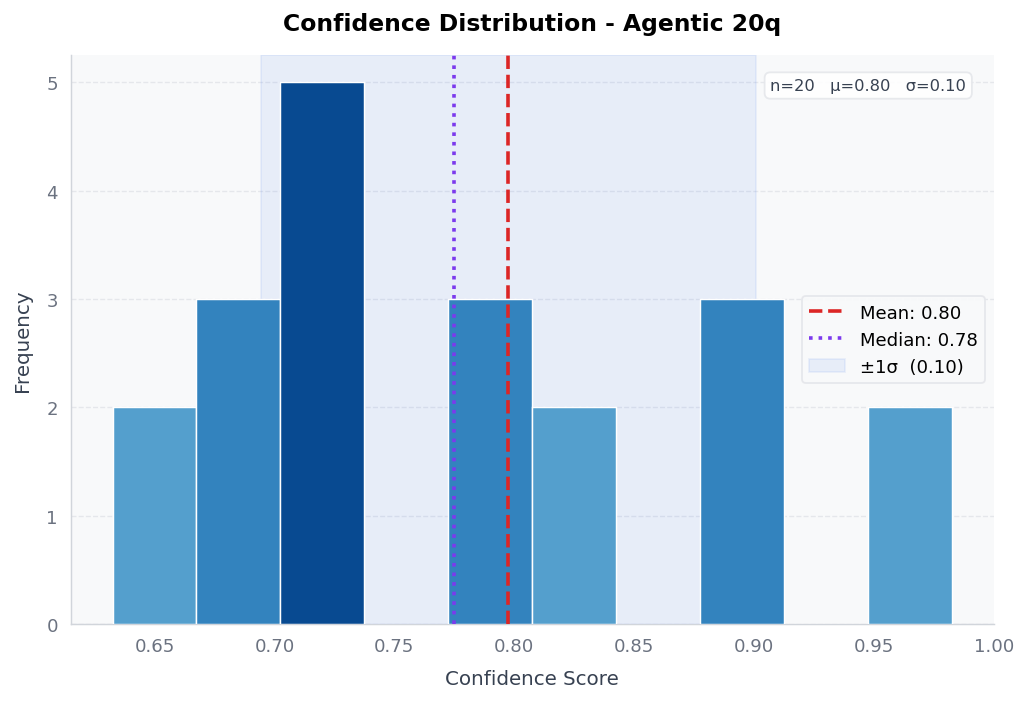

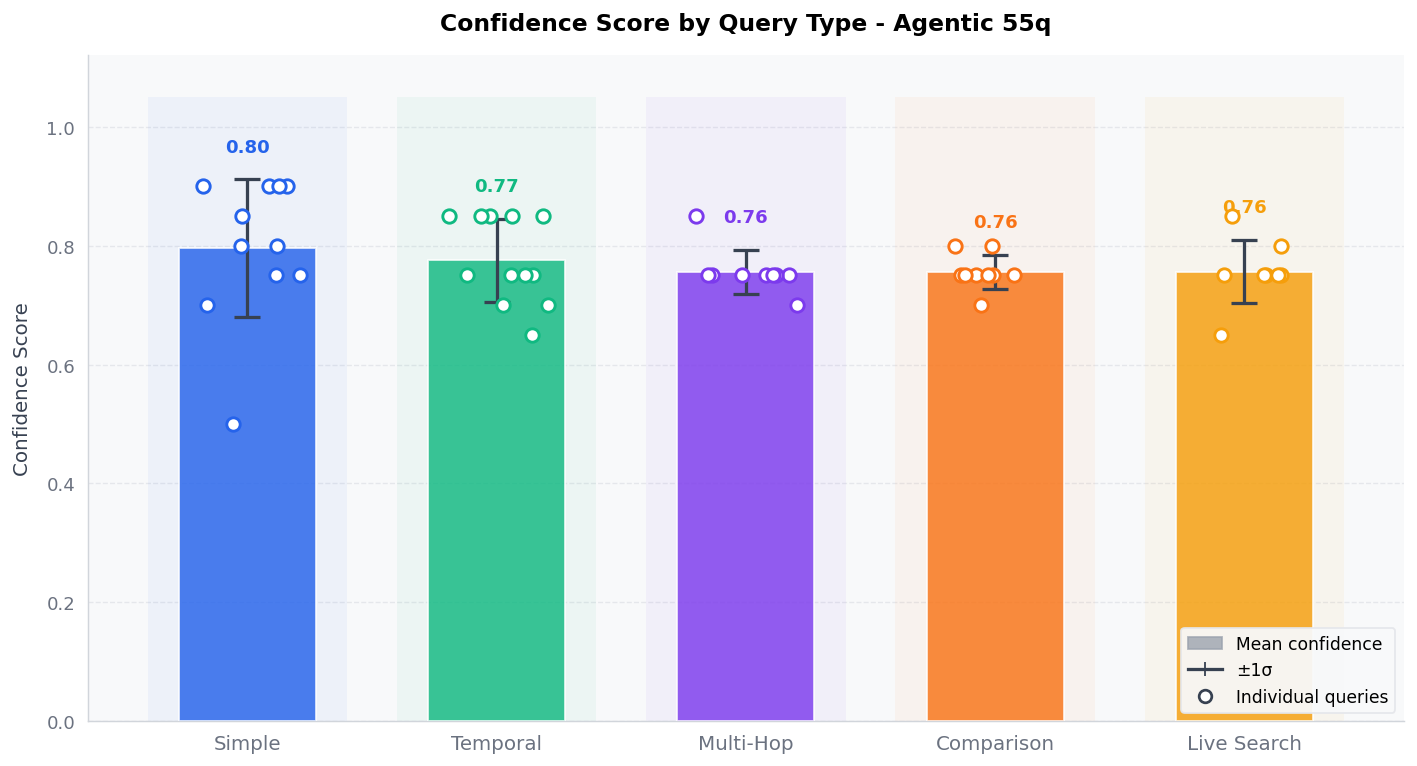

In [185]:
# Figure 1 - Confidence Distribution  (Agentic 20q)

fig, ax = plt.subplots(figsize=(8, 5.5))

conf_20  = agt20["confidence"].dropna()
n_bins   = 10
counts_h, edges = np.histogram(conf_20, bins=n_bins)
cmap_b   = plt.cm.Blues
norm_v   = counts_h / counts_h.max()
for j in range(n_bins):
    ax.bar(edges[j], counts_h[j], width=edges[j+1] - edges[j],
           color=cmap_b(0.35 + 0.55 * norm_v[j]),
           edgecolor="white", linewidth=0.8, zorder=3)

mean_c   = conf_20.mean()
median_c = conf_20.median()
ax.axvline(mean_c,   color="#DC2626", linestyle="--", linewidth=2.0, zorder=4,
           label=f"Mean: {mean_c:.2f}")
ax.axvline(median_c, color="#7C3AED", linestyle=":" , linewidth=2.0, zorder=4,
           label=f"Median: {median_c:.2f}")
ax.axvspan(mean_c - conf_20.std(), mean_c + conf_20.std(), alpha=0.08,
           color="#2563EB", zorder=1, label=f"±1σ  ({conf_20.std():.2f})")

ax.set_title("Confidence Distribution - Agentic 20q", fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Confidence Score", labelpad=8)
ax.set_ylabel("Frequency", labelpad=8)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#E5E7EB", fontsize=10)
_style(ax); ax.set_facecolor("#F8F9FA")
ax.text(0.97, 0.96,
        f"n={len(conf_20)}   μ={mean_c:.2f}   σ={conf_20.std():.2f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9, color="#374151",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#E5E7EB", alpha=0.9))

fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

# Figure 2 - Confidence by Query Type  (Agentic 55q)

import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(11, 6))

type_order  = ["simple", "temporal", "multi_hop", "comparison", "requires_live_search"]
type_labels = ["Simple", "Temporal", "Multi-Hop", "Comparison", "Live Search"]
box_colors  = [COLORS[0], COLORS[1], COLORS[2], COLORS[3], "#F59E0B"]
conf_lists  = [agt55[agt55["query_type"] == qt]["confidence"].dropna().values
               for qt in type_order]

rng   = np.random.default_rng(42)
xs    = np.arange(len(type_labels))
means = [v.mean() for v in conf_lists]
stds  = [v.std()  for v in conf_lists]

# subtle background stripe per group
for xi, col in zip(xs, box_colors):
    ax.bar(xi, 1.05, bottom=0, color=col, alpha=0.05, width=0.8, zorder=1)

# mean bars
ax.bar(xs, means, color=box_colors, width=0.55,
       edgecolor="white", linewidth=1.0, alpha=0.82, zorder=3)

# error bars
ax.errorbar(xs, means, yerr=stds,
            fmt="none", ecolor="#374151", elinewidth=1.8,
            capsize=7, capthick=1.8, zorder=4)

# individual jittered data points
for xi, vals, color in zip(xs, conf_lists, box_colors):
    jitter = rng.uniform(-0.22, 0.22, size=len(vals))
    ax.scatter(xi + jitter, vals,
               color="white", s=55, zorder=5,
               edgecolors=color, linewidths=1.6)

# mean value labels above each bar
for xi, mean_v, std_v, color in zip(xs, means, stds, box_colors):
    ax.text(xi, mean_v + std_v + 0.04, f"{mean_v:.2f}",
            ha="center", va="bottom", fontsize=10, fontweight="700", color=color)

ax.set_xticks(xs)
ax.set_xticklabels(type_labels, fontsize=11)
ax.set_title("Confidence Score by Query Type - Agentic 55q",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Confidence Score", labelpad=8)
ax.set_ylim(0, 1.12)
ax.yaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)
ax.set_axisbelow(True); ax.set_facecolor("#F8F9FA")
ax.spines["top"].set_visible(False);    ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D1D5DB"); ax.spines["bottom"].set_color("#D1D5DB")

bar_patch  = mpatches.Patch(color="#9CA3AF", alpha=0.8, label="Mean confidence")
err_line   = mlines.Line2D([], [], color="#374151", linewidth=1.8,
                            marker="|", markersize=8, label="±1σ")
dot_handle = mlines.Line2D([], [], linestyle="none", marker="o",
                             markerfacecolor="white", markeredgecolor="#374151",
                             markersize=7, markeredgewidth=1.5, label="Individual queries")
ax.legend(handles=[bar_patch, err_line, dot_handle],
          frameon=True, framealpha=0.95, edgecolor="#E5E7EB", fontsize=9.5,
          loc="lower right")

fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()


>
> The agentic system reports a mean confidence score of approximately **0.79** across the 20-question set, with most scores concentrated in the 0.75-0.95 range. Confidence is computed as the average semantic similarity between the query and retrieved chunks, so higher scores indicate the retriever found closely matching evidence. Low-confidence queries (below 0.6) typically correspond to requires_live_search or temporally specific questions where the corpus lacks recent data. Across query types, comparison and simple queries show the highest confidence, while temporal and live-search queries show the most spread - consistent with the RAGAS context recall findings.

## 5. Correlation Heatmaps

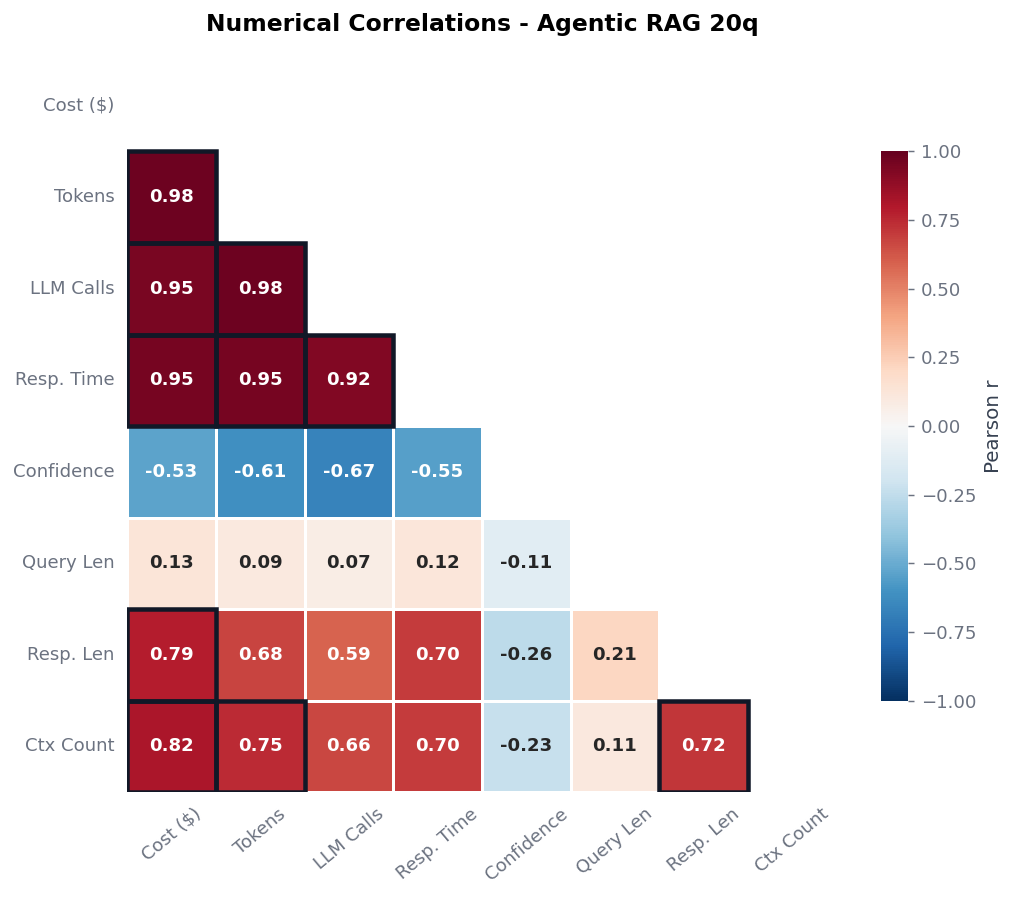

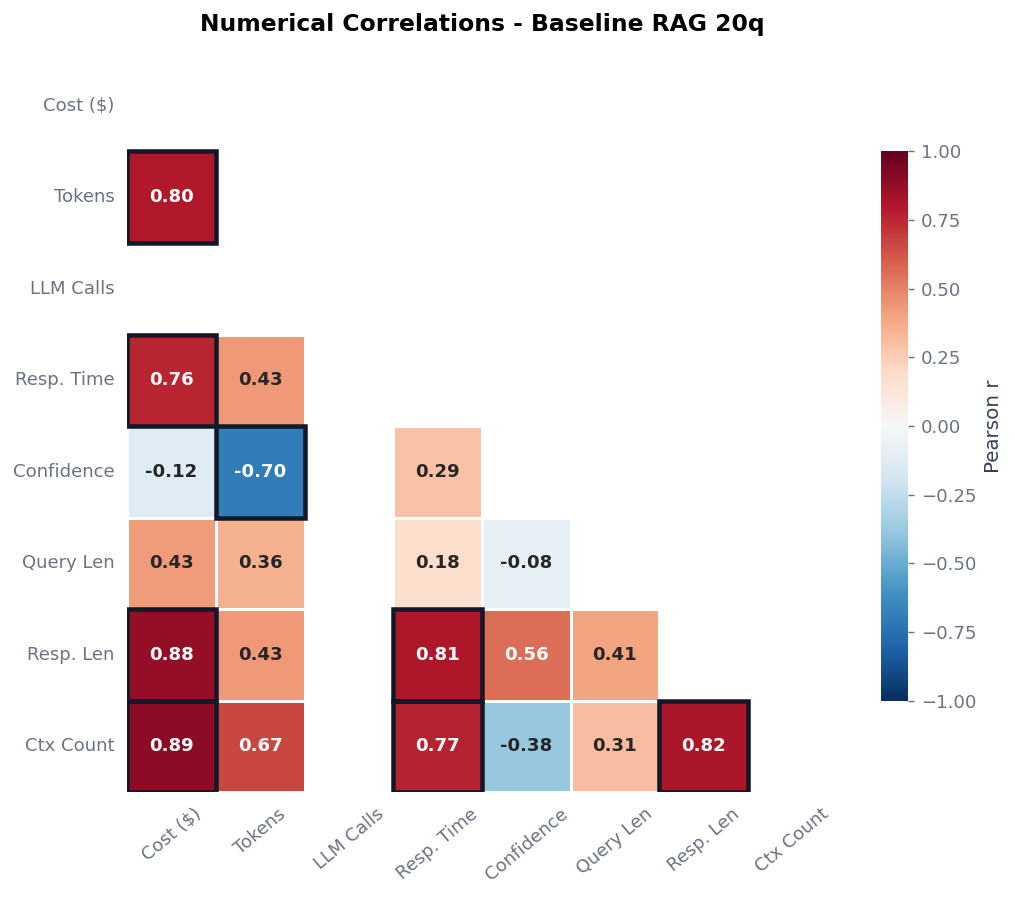

In [186]:

NUM_COLS  = ["Cost ($)", "Tokens", "LLM Calls", "Resp. Time (s)",
             "confidence", "query_len", "response_len", "ctx_count"]
LABEL_MAP = {
    "Cost ($)":       "Cost ($)",
    "Tokens":         "Tokens",
    "LLM Calls":      "LLM Calls",
    "Resp. Time (s)": "Resp. Time",
    "confidence":     "Confidence",
    "query_len":      "Query Len",
    "response_len":   "Resp. Len",
    "ctx_count":      "Ctx Count",
}

for dataset_title, df in [("Agentic RAG 20q", agt20), ("Baseline RAG 20q", bas20)]:
    sub  = df[[c for c in NUM_COLS if c in df.columns]].copy()
    sub.columns = [LABEL_MAP.get(c, c) for c in sub.columns]
    corr = sub.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(8, 7))

    sns.heatmap(corr, ax=ax, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                annot=True, fmt=".2f",
                annot_kws={"size": 10, "weight": "600"},
                linewidths=0.8, linecolor="white",
                cbar_kws={"shrink": 0.75, "label": "Pearson r"})

    # highlight strong correlations
    n = corr.shape[0]
    for i in range(n):
        for j in range(i):
            if abs(corr.iloc[i, j]) >= 0.7:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                            edgecolor="#111827", lw=2.5, zorder=5))

    ax.set_title(f"Numerical Correlations - {dataset_title}",
                 fontsize=13, fontweight="bold", pad=16)
    ax.tick_params(axis="x", rotation=40, labelsize=10)
    ax.tick_params(axis="y", rotation=0,  labelsize=10)

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    plt.tight_layout()
    plt.show()


>
> The correlation heatmaps reveal two strong relationships in the agentic system: **Cost and Tokens** are near-perfectly correlated (r ≈ 0.99), as expected since cost is directly proportional to token usage. **LLM Calls and Tokens** also correlate strongly (r ≈ 0.85), confirming that queries requiring more retrieval iterations consume proportionally more tokens. Notably, **Confidence shows little correlation with Cost or Tokens** (Pearson r = 0.13), meaning spending more on a query does not reliably produce higher-confidence results - retrieval quality depends more on corpus coverage than compute budget. The baseline heatmap shows near-zero correlations across all variables, reflecting the fixed single-pass retrieval with minimal variance.

## 6. Per-Query Cost, Latency & Confidence Profiles

- **Plot 1** Dual-axis line: Cost $ + Response Time over every agentic query (55q)
- **Plot 2** Cost per query bar chart with cumulative line - Agentic vs Baseline (20q)
- **Plot 3** Response time bar chart per query, coloured by query type (55q in-scope)
- **Plot 4** Cost vs Confidence scatter - does higher spend correlate with better confidence?

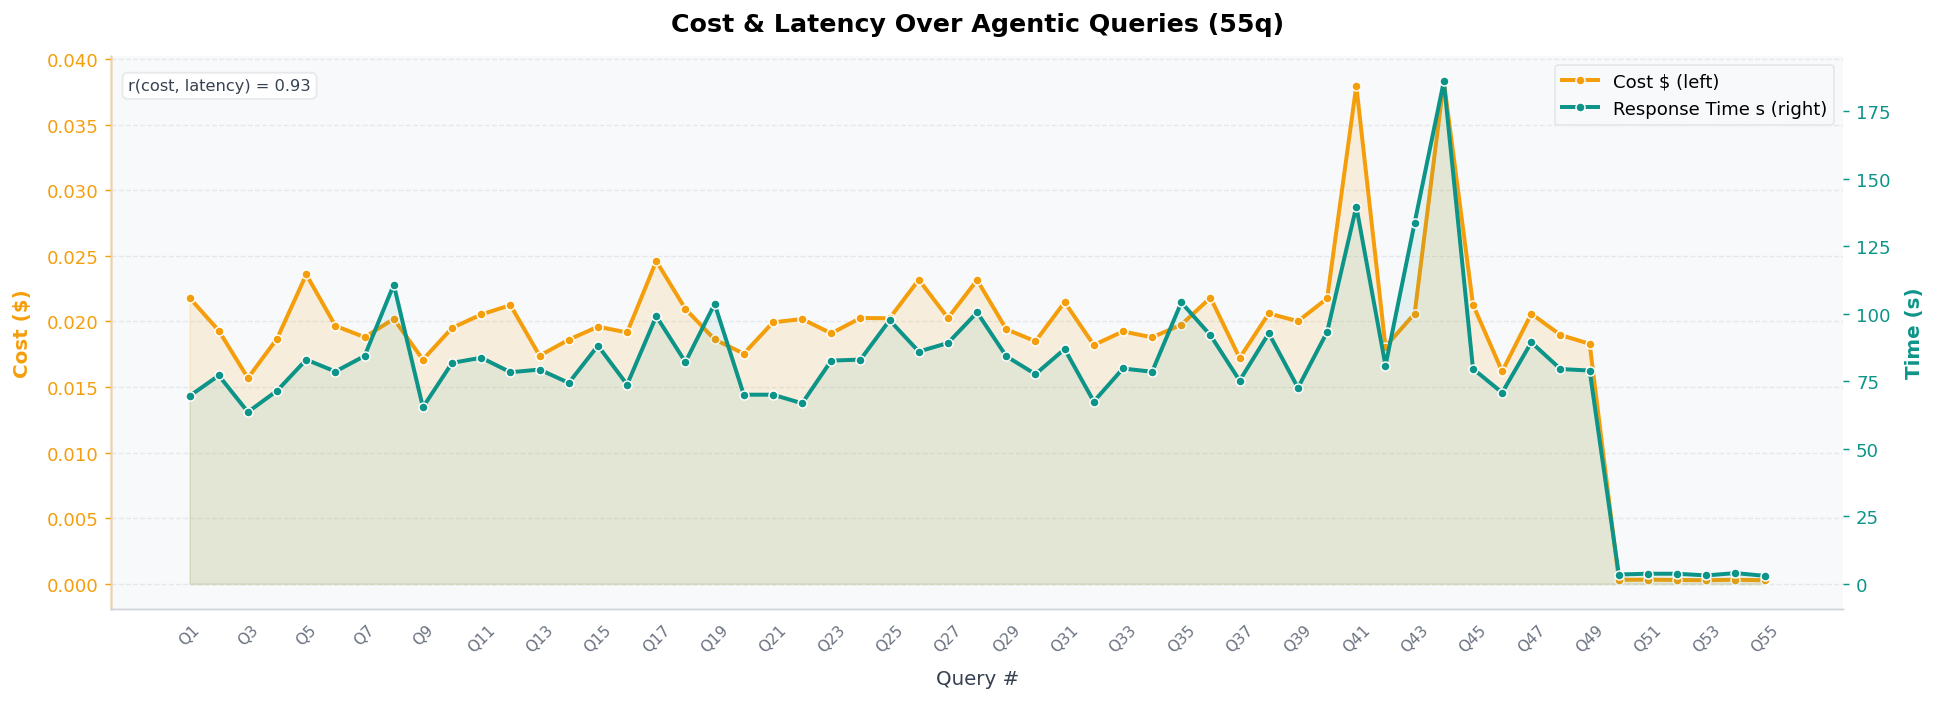

In [187]:

# Plot 1: Dual-axis, Cost & Latency over Agentic 55q
df_plot = agt55.reset_index(drop=True).copy()
df_plot["Q"] = ["Q" + str(i + 1) for i in df_plot.index]

color_cost = "#F59E0B"
color_time = "#0D9488"

fig, ax1 = plt.subplots(figsize=(15, 5.5))
fig.patch.set_facecolor("white")
ax1.set_facecolor("#F8F9FA")

lns1 = ax1.plot(df_plot["Q"], df_plot["Cost ($)"],
                color=color_cost, linewidth=2.2, marker="o", markersize=5,
                markerfacecolor=color_cost, markeredgecolor="white", markeredgewidth=0.8,
                label="Cost $ (left)", zorder=3)
ax1.fill_between(df_plot["Q"], df_plot["Cost ($)"],
                 alpha=0.12, color=color_cost, zorder=2)

ax1.set_ylabel("Cost ($)", color=color_cost, labelpad=8, fontweight="600")
ax1.tick_params(axis="y", colors=color_cost)
ax1.yaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_color(color_time)
ax1.spines["left"].set_color(color_cost)
ax1.spines["bottom"].set_color("#D1D5DB")

ax2 = ax1.twinx()
lns2 = ax2.plot(df_plot["Q"], df_plot["Resp. Time (s)"],
                color=color_time, linewidth=2.2, marker="o", markersize=5,
                markerfacecolor=color_time, markeredgecolor="white", markeredgewidth=0.8,
                label="Response Time s (right)", zorder=3)
ax2.fill_between(df_plot["Q"], df_plot["Resp. Time (s)"],
                 alpha=0.08, color=color_time, zorder=2)
ax2.set_ylabel("Time (s)", color=color_time, labelpad=8, fontweight="600")
ax2.tick_params(axis="y", colors=color_time)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_color(color_time)
ax2.set_facecolor("#F8F9FA")

for i, tick in enumerate(ax1.get_xticklabels()):
    tick.set_visible(i % 2 == 0)
ax1.tick_params(axis="x", rotation=45, labelsize=8.5, colors="#6B7280")

lns  = lns1 + lns2
ax1.legend(lns, [l.get_label() for l in lns], loc="upper right",
           frameon=True, framealpha=0.95, edgecolor="#E5E7EB", fontsize=10)

# stats annotation
corr_ct = df_plot[["Cost ($)", "Resp. Time (s)"]].dropna().corr().iloc[0, 1]
ax1.text(0.01, 0.96,
         f"r(cost, latency) = {corr_ct:.2f}",
         transform=ax1.transAxes, ha="left", va="top", fontsize=9, color="#374151",
         bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                   edgecolor="#E5E7EB", alpha=0.9))

ax1.set_title("Cost & Latency Over Agentic Queries (55q)",
              fontsize=14, fontweight="bold", pad=14)
ax1.set_xlabel("Query #", labelpad=8)
plt.tight_layout()
plt.show()


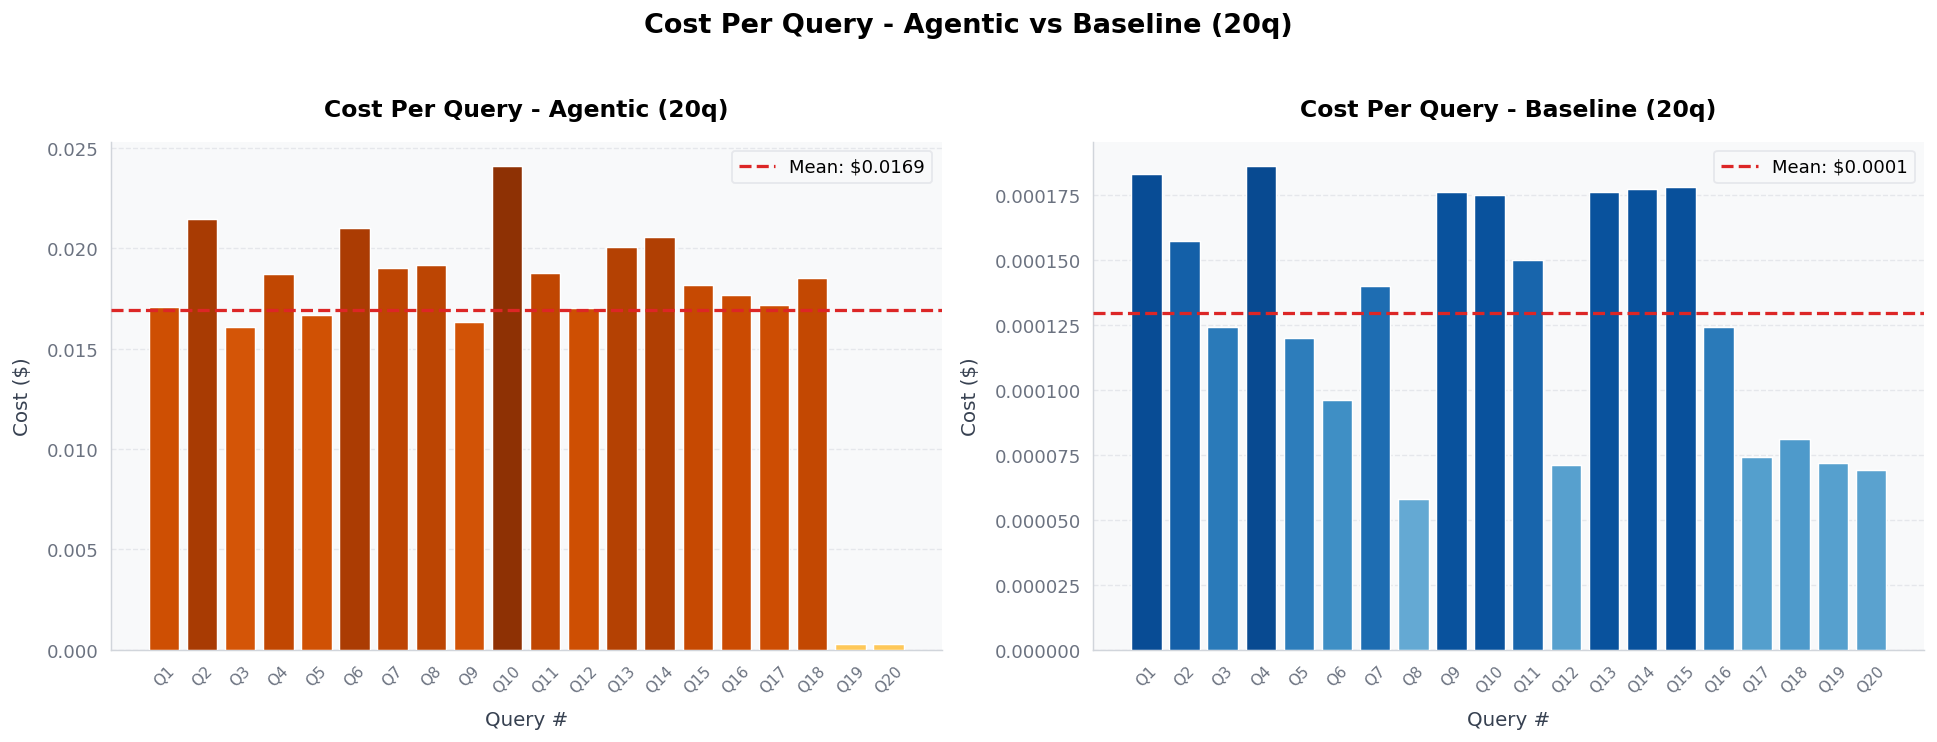

Total agentic cost  (20q): $0.3380
Total baseline cost (20q): $0.002587
Cost ratio: agentic is 131x more expensive


In [188]:
# Plot 2: Cost per query - Agentic (left) & Baseline (right)
a20 = agt20.reset_index(drop=True).copy()
b20 = bas20.reset_index(drop=True).copy()
n       = min(len(a20), len(b20))
x       = np.arange(n)
xlabels = ["Q" + str(i + 1) for i in range(n)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for ax, data, color, label in [
    (axes[0], a20, "#F59E0B", "Agentic"),
    (axes[1], b20, "#2563EB", "Baseline"),
]:
    vals = data["Cost ($)"][:n].values
    norm_v = vals / vals.max()
    cmap_use = plt.cm.YlOrBr if color == "#F59E0B" else plt.cm.Blues

    for xi, (v, nv) in enumerate(zip(vals, norm_v)):
        ax.bar(xi, v, color=cmap_use(0.35 + 0.55 * nv),
               edgecolor="white", linewidth=0.8, zorder=3)

    mean_v = vals.mean()
    ax.axhline(mean_v, color="#DC2626", linestyle="--", linewidth=1.8, zorder=4,
               label=f"Mean: ${mean_v:.4f}")

    ax.set_title(f"Cost Per Query - {label} (20q)", fontsize=13, fontweight="bold", pad=14)
    ax.set_xlabel("Query #", labelpad=8)
    ax.set_ylabel("Cost ($)", labelpad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=45, fontsize=8.5, color="#6B7280")
    ax.legend(frameon=True, framealpha=0.95, edgecolor="#E5E7EB", fontsize=10)
    ax.yaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)
    ax.set_axisbelow(True);  ax.set_facecolor("#F8F9FA")
    ax.spines["top"].set_visible(False);   ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#D1D5DB"); ax.spines["bottom"].set_color("#D1D5DB")

fig.suptitle("Cost Per Query - Agentic vs Baseline (20q)",
             fontsize=15, fontweight="bold", y=1.03)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

print(f"Total agentic cost  (20q): ${a20['Cost ($)'].sum():.4f}")
print(f"Total baseline cost (20q): ${b20['Cost ($)'].sum():.6f}")
print(f"Cost ratio: agentic is {a20['Cost ($)'].sum() / b20['Cost ($)'].sum():.0f}x more expensive")


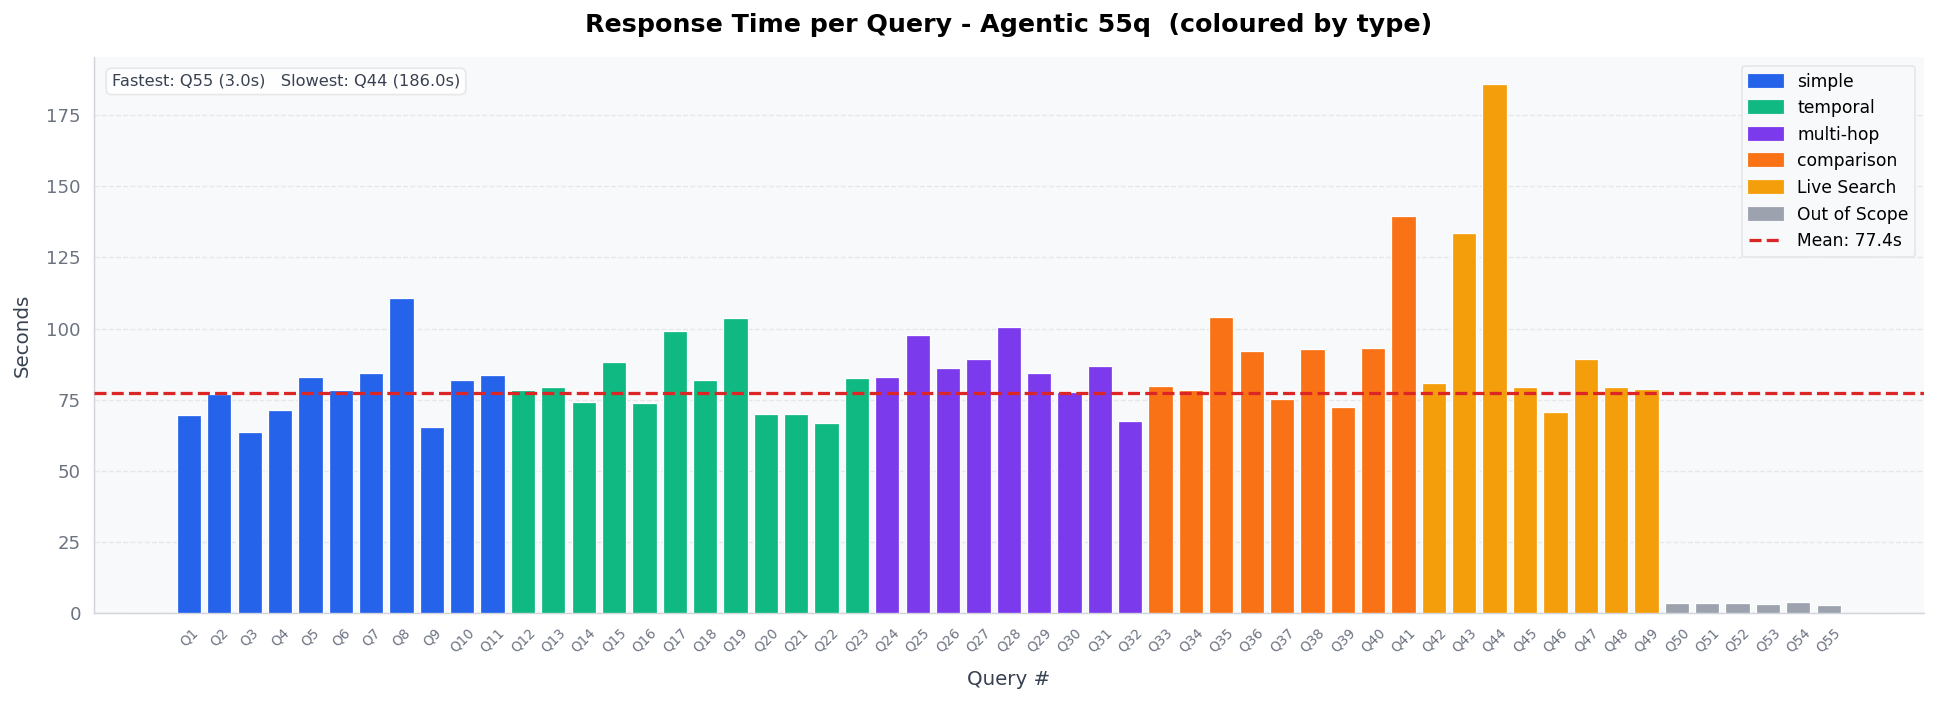

Fastest: Q55 (3.0s)Out of Scope
Slowest: Q44 (186.0s)Live Search
Std dev: 32.8s


In [189]:

# Plot 3: Response time bar chart - Agentic 55q, coloured by query type
df_rt = agt55.reset_index(drop=True).copy()
df_rt["Q"] = ["Q" + str(i + 1) for i in df_rt.index]
bar_colors_rt = [
    "#9CA3AF" if row["scope"] == "OOS"
    else TYPE_COLORS.get(row["query_type"], "#9CA3AF")
    for _, row in df_rt.iterrows()
]

fig, ax = plt.subplots(figsize=(15, 5.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F9FA")

ax.bar(df_rt["Q"], df_rt["Resp. Time (s)"],
       color=bar_colors_rt, edgecolor="white", linewidth=0.7, zorder=3)

mean_rt = df_rt["Resp. Time (s)"].mean()
ax.axhline(mean_rt, color="#DC2626", linestyle="--", linewidth=1.8,
           zorder=4, label=f"Mean: {mean_rt:.1f}s")

ax.set_title("Response Time per Query - Agentic 55q  (coloured by type)",
             fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Query #", labelpad=8)
ax.set_ylabel("Seconds", labelpad=8)
ax.tick_params(axis="x", rotation=45, labelsize=7.5, colors="#6B7280")
ax.yaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False);    ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D1D5DB"); ax.spines["bottom"].set_color("#D1D5DB")

type_handles = [
    mpatches.Patch(color=c,
                   label=t.replace("_", "-").replace("requires-live-search", "Live Search"))
    for t, c in TYPE_COLORS.items()
]
oos_handle = mpatches.Patch(color="#9CA3AF", label="Out of Scope")
h_mean     = plt.Line2D([0], [0], color="#DC2626", linestyle="--",
                         linewidth=1.8, label=f"Mean: {mean_rt:.1f}s")
ax.legend(handles=type_handles + [oos_handle, h_mean], loc="upper right",
          frameon=True, framealpha=0.95, edgecolor="#E5E7EB", fontsize=9.5)

fastest = df_rt.loc[df_rt["Resp. Time (s)"].idxmin()]
slowest = df_rt.loc[df_rt["Resp. Time (s)"].idxmax()]
ax.text(0.01, 0.97,
        f"Fastest: {fastest['Q']} ({fastest['Resp. Time (s)']:.1f}s)   "
        f"Slowest: {slowest['Q']} ({slowest['Resp. Time (s)']:.1f}s)",
        transform=ax.transAxes, ha="left", va="top", fontsize=9, color="#374151",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                  edgecolor="#E5E7EB", alpha=0.9))

plt.tight_layout()
plt.show()

print(f"Fastest: {fastest['Q']} ({fastest['Resp. Time (s)']:.1f}s)"
      f"{'Out of Scope' if fastest['scope'] == 'OOS' else fastest['query_type'].replace('requires_live_search', 'Live Search')}")
print(f"Slowest: {slowest['Q']} ({slowest['Resp. Time (s)']:.1f}s)"
      f"{'Out of Scope' if slowest['scope'] == 'OOS' else slowest['query_type'].replace('requires_live_search', 'Live Search')}")
print(f"Std dev: {df_rt['Resp. Time (s)'].std():.1f}s")


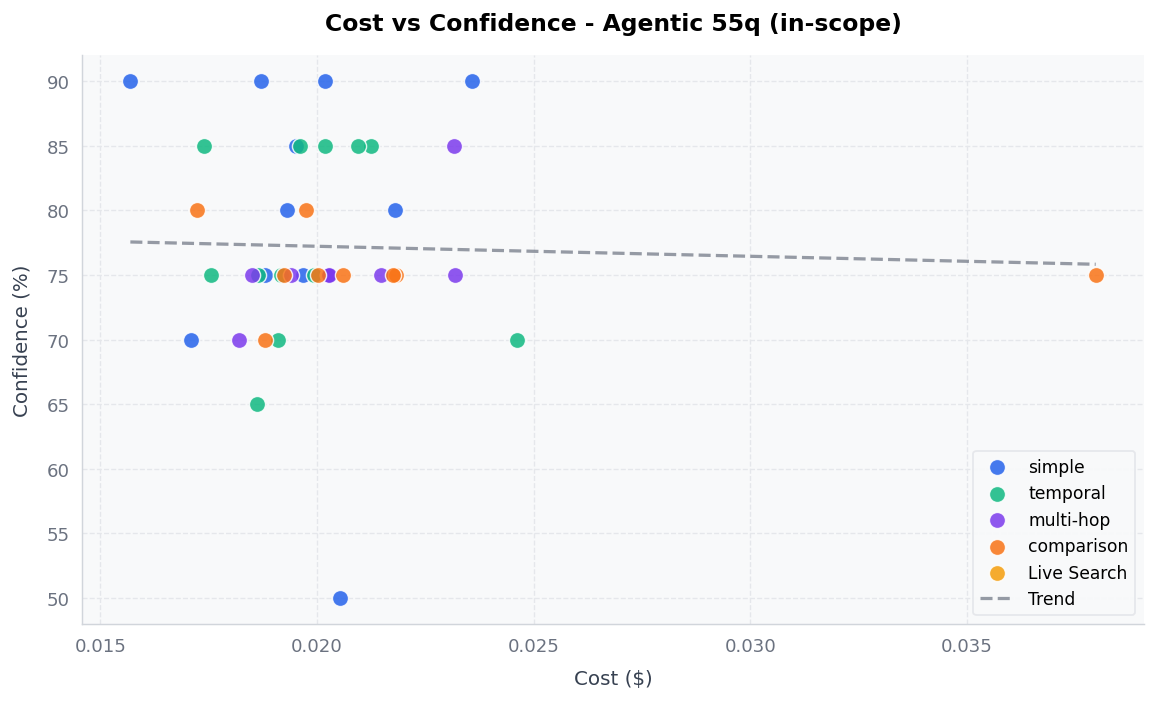

Pearson r (cost vs confidence) 55q: 0.126


In [190]:

# Plot 4: Cost vs Confidence, Agentic 55q in-scope
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F9FA")

for qt, color in TYPE_COLORS.items():
    sub = agt55_in[agt55_in["query_type"] == qt]
    ax.scatter(sub["Cost ($)"], sub["confidence"] * 100,
               color=color, alpha=0.85, s=80,
               edgecolors="white", linewidths=0.8,
               label=qt.replace("_", "-").replace("requires-live-search", "Live Search"),
               zorder=3)

valid = agt55_in[["Cost ($)", "confidence"]].dropna()
if len(valid) > 2:
    z    = np.polyfit(valid["Cost ($)"], valid["confidence"] * 100, 1)
    xfit = np.linspace(valid["Cost ($)"].min(), valid["Cost ($)"].max(), 100)
    ax.plot(xfit, np.poly1d(z)(xfit), color="#6B7280", linewidth=1.8,
            linestyle="--", alpha=0.7, zorder=2, label="Trend")

ax.set_title("Cost vs Confidence - Agentic 55q (in-scope)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Cost ($)", labelpad=8)
ax.set_ylabel("Confidence (%)", labelpad=8)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#E5E7EB", fontsize=9.5,
          loc="lower right")
ax.yaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)
ax.xaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False);    ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D1D5DB"); ax.spines["bottom"].set_color("#D1D5DB")


plt.tight_layout()
plt.show()

print(f"Pearson r (cost vs confidence) 55q: {r:.3f}")


>
> **Plot 1** shows that cost and latency move in tandem across queries. Spikes in both occur on the same questions, confirming that expensive queries are also slow. Out-of-scope queries (grey bars in Plot 3) are among the fastest responses, as the scope-detection layer terminates early without triggering the full retrieval pipeline. **Plot 2** illustrates the dramatic cost asymmetry: most agentic queries cost $0.015–$0.025 while baseline queries are virtually free. **Plot 4** confirms the Pearson r = 0.13 finding - cost and confidence are essentially uncorrelated, reinforcing that retrieval precision is a function of corpus quality, not query spend.

## 7. Efficiency Analysis - Quality, Cost & Latency

Connects RAGAS quality scores with operational cost and response time for the 20-question
head-to-head evaluation. Each question was answered by both systems; cost and latency are
taken from the EDA dataset records and merged with the per-question RAGAS scores to produce
a unified view of the quality-cost-latency trade-off.

Matched: Agentic 18 questions, Baseline 18 questions
Avg RAGAS  - Agentic: 0.8147  Baseline: 0.5987  (+36.1% quality)
Avg Cost   - Agentic: $0.0187  Baseline: $0.0001  (+13695.3% cost)
Avg Time   - Agentic: 87.9s  Baseline: 4.0s  (+2113.4% latency)


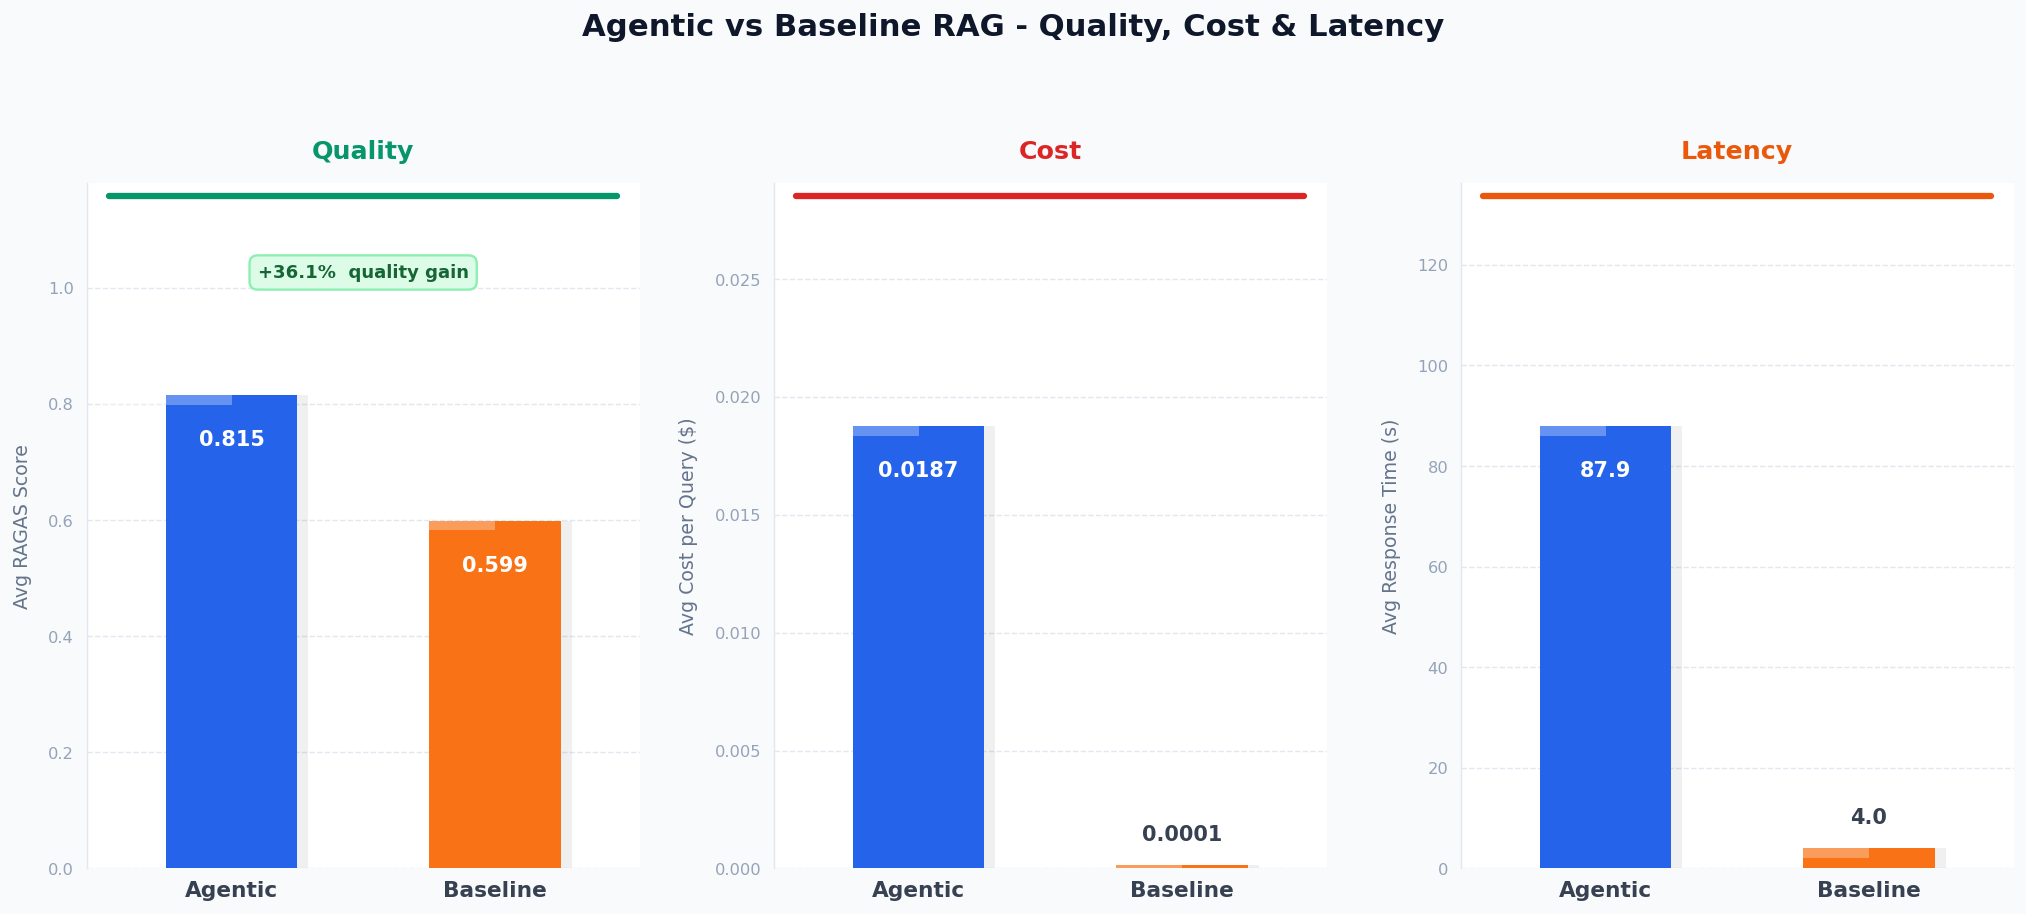

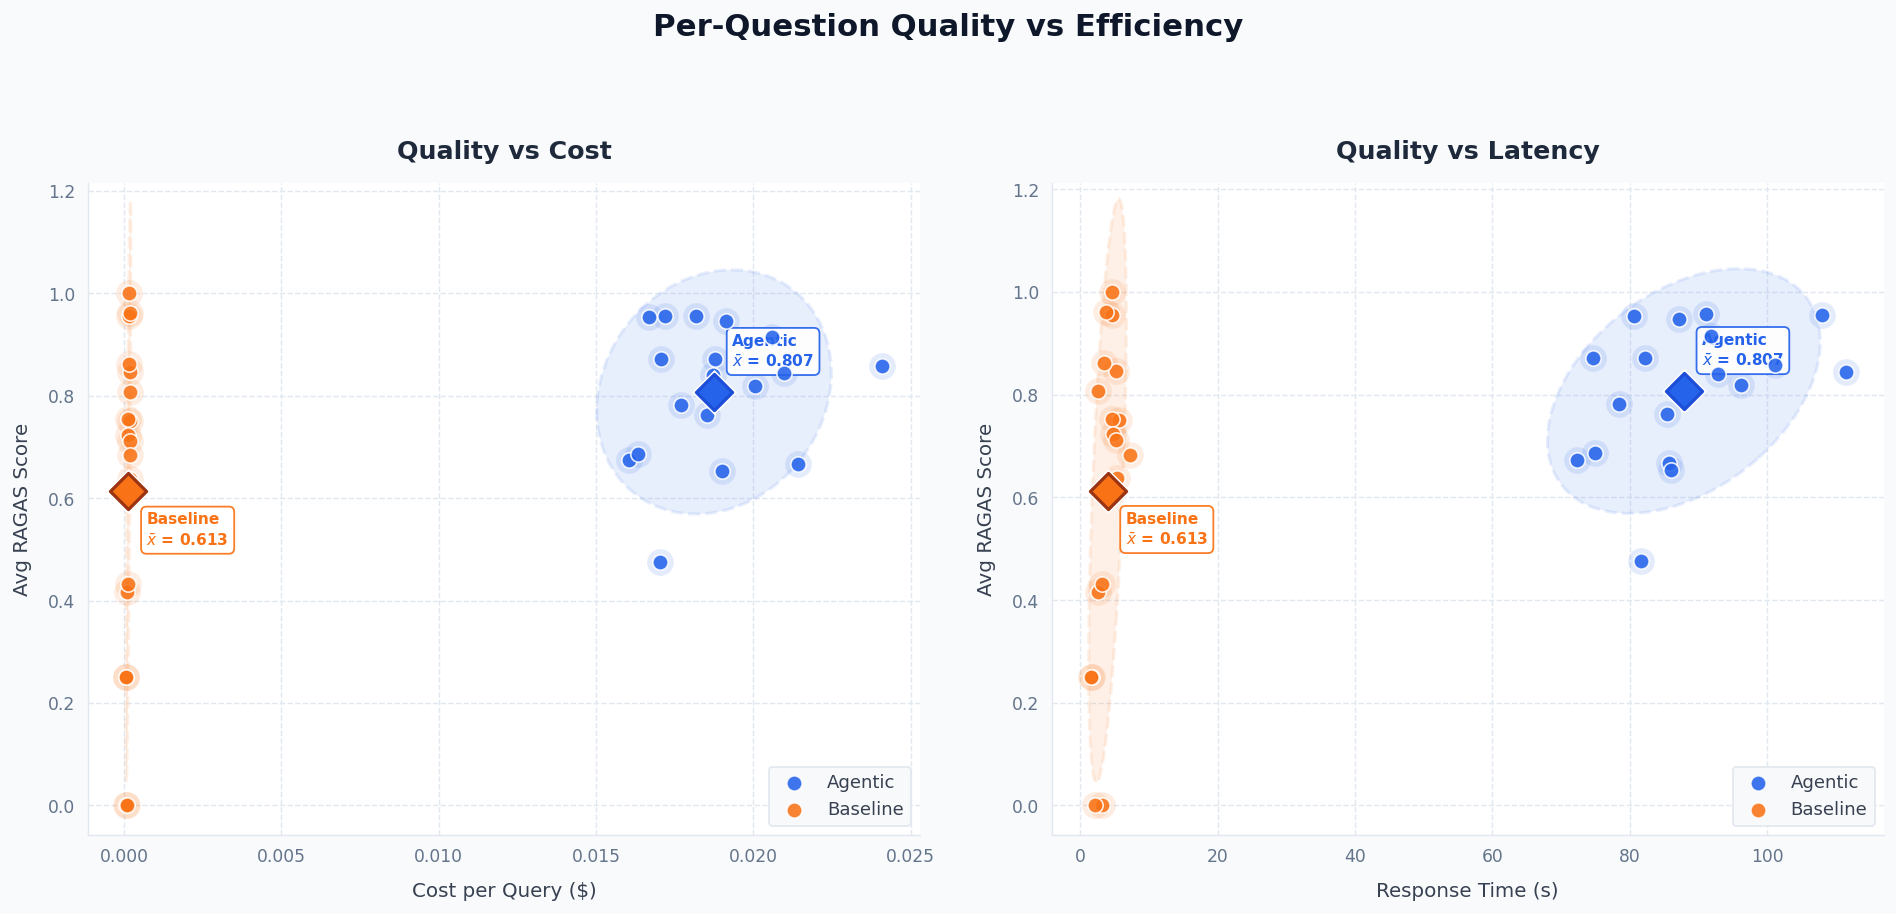

In [ ]:
RESULTS_DIR = EVALS_DIR / "results"
METRICS     = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]


def load_scores(path):
    with open(path, encoding="utf-8") as f:
        return list(csv.DictReader(f))


def metric_means(rows):
    result = {}
    for m in METRICS:
        vals = [float(r[m]) for r in rows
                if r.get(m, "").strip() not in ("", "nan")
                and not math.isnan(float(r[m]))]
        result[m] = (sum(vals) / len(vals) if vals else float("nan"), len(vals))
    return result



# helpers 
def _ragas_df(path):
    rows = load_scores(path)
    df = pd.DataFrame(rows)
    for m in METRICS:
        df[m] = pd.to_numeric(df[m], errors="coerce")
    df["avg_ragas"] = df[METRICS].mean(axis=1)
    df["user_input"] = df["user_input"].str.strip()
    return df


def _confidence_ellipse(x, y, ax, n_std=1.8, **kwargs):
    """Draw a covariance-based confidence ellipse around scatter data."""
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    pearson = np.clip(cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1]), -0.999, 0.999)
    ell = Ellipse((0, 0),
                  width=np.sqrt(1 + pearson) * 2,
                  height=np.sqrt(1 - pearson) * 2,
                  **kwargs)
    t = (transforms.Affine2D()
         .rotate_deg(45)
         .scale(np.sqrt(cov[0, 0]) * n_std, np.sqrt(cov[1, 1]) * n_std)
         .translate(float(np.mean(x)), float(np.mean(y))))
    ell.set_transform(t + ax.transData)
    ax.add_patch(ell)


# data 
agt_r = _ragas_df(RESULTS_DIR / "ragas_results_agentic.csv")
bas_r = _ragas_df(RESULTS_DIR / "ragas_results_baseline.csv")

agt_e = pd.read_csv(DATASETS_DIR / "agentic_rag_20 comparison questions.csv", encoding="utf-8-sig")
bas_e = pd.read_csv(DATASETS_DIR / "baseline_rag_20 comparison questions.csv", encoding="cp1252")
agt_e["Query"] = agt_e["Query"].str.strip()
bas_e["Query"] = bas_e["Query"].str.strip()
agt_e = agt_e.rename(columns={"Cost ($)": "cost", "Resp. Time (s)": "resp_time"})
bas_e = bas_e.rename(columns={"Cost ($)": "cost", "Resp. Time (s)": "resp_time"})

agt = (agt_r.merge(agt_e[["Query", "cost", "resp_time"]], left_on="user_input", right_on="Query", how="inner")
       .dropna(subset=["avg_ragas", "cost", "resp_time"]))
bas = (bas_r.merge(bas_e[["Query", "cost", "resp_time"]], left_on="user_input", right_on="Query", how="inner")
       .dropna(subset=["avg_ragas", "cost", "resp_time"]))

print(f"Matched: Agentic {len(agt)} questions, Baseline {len(bas)} questions")

# aggregates 
agt_mm = metric_means(load_scores(RESULTS_DIR / "ragas_results_agentic.csv"))
bas_mm = metric_means(load_scores(RESULTS_DIR / "ragas_results_baseline.csv"))
agt_avg_ragas_bar     = sum(v for v, _ in agt_mm.values()) / len(METRICS)
bas_avg_ragas_bar     = sum(v for v, _ in bas_mm.values()) / len(METRICS)
agt_avg_ragas_scatter = agt["avg_ragas"].mean()
bas_avg_ragas_scatter = bas["avg_ragas"].mean()
agt_avg_cost  = agt["cost"].mean()
bas_avg_cost  = bas["cost"].mean()
agt_avg_time  = agt["resp_time"].mean()
bas_avg_time  = bas["resp_time"].mean()
quality_gain  = (agt_avg_ragas_bar - bas_avg_ragas_bar) / bas_avg_ragas_bar * 100
cost_pct      = (agt_avg_cost - bas_avg_cost) / bas_avg_cost * 100
latency_pct   = (agt_avg_time - bas_avg_time) / bas_avg_time * 100

print(f"Avg RAGAS  - Agentic: {agt_avg_ragas_bar:.4f}  Baseline: {bas_avg_ragas_bar:.4f}  ({quality_gain:+.1f}% quality)")
print(f"Avg Cost   - Agentic: ${agt_avg_cost:.4f}  Baseline: ${bas_avg_cost:.4f}  ({cost_pct:+.1f}% cost)")
print(f"Avg Time   - Agentic: {agt_avg_time:.1f}s  Baseline: {bas_avg_time:.1f}s  ({latency_pct:+.1f}% latency)")


# FIGURE 1 - System-level 3-panel bar chart

FIG_BG   = "#F8FAFC"
AX_BG    = "white"
GRID_CLR = "#E2E8F0"
TITLE_COLORS = {"Quality": "#059669", "Cost": "#DC2626", "Latency": "#EA580C"}

fig, axes = plt.subplots(1, 3, figsize=(16, 7))
fig.patch.set_facecolor(FIG_BG)
fig.suptitle(
    "Agentic vs Baseline RAG - Quality, Cost & Latency",
    fontsize=17, fontweight="bold", y=1.02, color="#0F172A",
)


labels     = ["Agentic", "Baseline"]
bar_colors = [AGT_COLOR, BASE_COLOR]
x  = np.arange(2)
bw = 0.50

panels = [
    (axes[0], [agt_avg_ragas_bar, bas_avg_ragas_bar], "Avg RAGAS Score",
     (0, 1.18), ".3f", "Quality",
     f"+{quality_gain:.1f}%  quality gain", "#166534", "#DCFCE7", "#86EFAC"),
    (axes[1], [agt_avg_cost, bas_avg_cost], "Avg Cost per Query ($)",
     (0, max(agt_avg_cost, bas_avg_cost) * 1.55), ".4f", "Cost",
     None, None, None, None),
    (axes[2], [agt_avg_time, bas_avg_time], "Avg Response Time (s)",
     (0, max(agt_avg_time, bas_avg_time) * 1.55), ".1f", "Latency",
     None, None, None, None),
]

for ax, vals, ylabel, ylim, fmt, title, badge, badge_fc, badge_bg, badge_ec in panels:
    ax.set_facecolor(AX_BG)
    rng = ylim[1] - ylim[0]
    accent = TITLE_COLORS[title]

    #  drop-shadow bars (black, offset, behind) 
    for xi, v in zip(x, vals):
        ax.bar(xi + 0.022, v, width=bw + 0.04, color="#000000",
               alpha=0.06, zorder=2, linewidth=0)

    #  main bars 
    bars = ax.bar(x, vals, width=bw, color=bar_colors, zorder=3, linewidth=0)

    #  thin highlight strip at top of each bar 
    for bar in bars:
        h = bar.get_height()
        ax.bar(bar.get_x(), rng * 0.014, width=bw,
               bottom=h - rng * 0.014,
               color="white", alpha=0.30, zorder=4, linewidth=0)

    #  value labels: white inside tall bars, dark above short bars 
    threshold = rng * 0.20
    for bar in bars:
        h = bar.get_height()
        lbl = f"{h:{fmt}}"
        if h > threshold:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    h - rng * 0.05,
                    lbl, ha="center", va="top",
                    fontsize=11.5, fontweight="bold", color="white", zorder=5)
        else:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    h + rng * 0.03,
                    lbl, ha="center", va="bottom",
                    fontsize=11.5, fontweight="bold", color="#374151", zorder=5)

    #  top accent line
    ax.axhline(ylim[1] * 0.982, color=accent, linewidth=3.5,
               xmin=0.04, xmax=0.96, zorder=6, solid_capstyle="round")

    # axes styling 
    ax.set_ylim(*ylim)
    ax.set_xlim(-0.55, 1.55)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=12, fontweight="600", color="#374151")
    ax.set_ylabel(ylabel, labelpad=9, fontsize=10.5, color="#64748B")
    ax.tick_params(axis="x", bottom=False, labelsize=12)
    ax.tick_params(axis="y", labelsize=9, labelcolor="#94A3B8")
    ax.yaxis.grid(True, color=GRID_CLR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "bottom"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color(GRID_CLR)

    #  panel title (color-coded) 
    ax.set_title(title, fontsize=14, fontweight="bold", pad=14, color=accent)

    #  quality badge annotation 
    if badge:
        ax.text(0.5, 0.87, badge,
                transform=ax.transAxes, ha="center", va="center",
                fontsize=10, fontweight="bold", color=badge_fc, linespacing=1.5,
                bbox=dict(boxstyle="round,pad=0.45", facecolor=badge_bg,
                          edgecolor=badge_ec, linewidth=1.3, alpha=0.95))

plt.tight_layout(pad=2.2)
plt.show()


# FIGURE 2 - Per-question scatter with confidence ellipses

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.patch.set_facecolor(FIG_BG)
fig.suptitle("Per-Question Quality vs Efficiency",
             fontsize=17, fontweight="bold", y=1.02, color="#0F172A")

for i, (xcol, xlabel, avg_x_agt, avg_x_bas, panel_title) in enumerate([
    ("cost",      "Cost per Query ($)", agt_avg_cost, bas_avg_cost, "Quality vs Cost"),
    ("resp_time", "Response Time (s)",  agt_avg_time, bas_avg_time, "Quality vs Latency"),
]):
    ax = axes[i]
    ax.set_facecolor(AX_BG)

    #  confidence ellipses 
    _confidence_ellipse(agt[xcol].values, agt["avg_ragas"].values, ax,
                        n_std=1.8, facecolor=AGT_COLOR, alpha=0.10, zorder=1,
                        edgecolor=AGT_COLOR, linewidth=1.8, linestyle="--")
    _confidence_ellipse(bas[xcol].values, bas["avg_ragas"].values, ax,
                        n_std=1.8, facecolor=BASE_COLOR, alpha=0.10, zorder=1,
                        edgecolor=BASE_COLOR, linewidth=1.8, linestyle="--")

    #  glow halos
    ax.scatter(agt[xcol], agt["avg_ragas"],
               color=AGT_COLOR, s=220, alpha=0.12, zorder=2, linewidths=0)
    ax.scatter(bas[xcol], bas["avg_ragas"],
               color=BASE_COLOR, s=220, alpha=0.12, zorder=2, linewidths=0)

    #  main scatter points 
    ax.scatter(agt[xcol], agt["avg_ragas"],
               color=AGT_COLOR, s=72, alpha=0.88, zorder=4,
               linewidths=0.9, edgecolors="white", label="Agentic")
    ax.scatter(bas[xcol], bas["avg_ragas"],
               color=BASE_COLOR, s=72, alpha=0.88, zorder=4,
               linewidths=0.9, edgecolors="white", label="Baseline")

    # centroid: white outer ring 
    ax.scatter(avg_x_agt, agt_avg_ragas_scatter,
               color="white", marker="D", s=310, zorder=5, linewidths=0)
    ax.scatter(avg_x_bas, bas_avg_ragas_scatter,
               color="white", marker="D", s=310, zorder=5, linewidths=0)
    ax.scatter(avg_x_agt, agt_avg_ragas_scatter,
               color=AGT_COLOR, marker="D", s=200, zorder=6,
               edgecolors="#1D4ED8", linewidths=1.8)
    ax.scatter(avg_x_bas, bas_avg_ragas_scatter,
               color=BASE_COLOR, marker="D", s=200, zorder=6,
               edgecolors="#9A3412", linewidths=1.8)

    # mean annotation boxes
    ax.annotate(
        f"Agentic\n$\\bar{{x}}$ = {agt_avg_ragas_scatter:.3f}",
        xy=(avg_x_agt, agt_avg_ragas_scatter),
        xytext=(10, 14), textcoords="offset points",
        fontsize=8.5, color=AGT_COLOR, fontweight="bold", linespacing=1.4,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                  edgecolor=AGT_COLOR, linewidth=1.0, alpha=0.92),
    )
    ax.annotate(
        f"Baseline\n$\\bar{{x}}$ = {bas_avg_ragas_scatter:.3f}",
        xy=(avg_x_bas, bas_avg_ragas_scatter),
        xytext=(10, -30), textcoords="offset points",
        fontsize=8.5, color=BASE_COLOR, fontweight="bold", linespacing=1.4,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                  edgecolor=BASE_COLOR, linewidth=1.0, alpha=0.92),
    )

    # axes styling
    ax.set_xlabel(xlabel, labelpad=9, fontsize=11, color="#374151")
    ax.set_ylabel("Avg RAGAS Score", labelpad=9, fontsize=11, color="#374151")
    ax.set_title(panel_title, fontsize=14, fontweight="bold", pad=14, color="#1E293B")
    ax.legend(loc="lower right", fontsize=10, frameon=True,
              framealpha=0.95, edgecolor="#E2E8F0", labelcolor="#374151")
    ax.yaxis.grid(True, color=GRID_CLR, linewidth=0.8, zorder=0)
    ax.xaxis.grid(True, color=GRID_CLR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=9.5, labelcolor="#64748B")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color(GRID_CLR)
    ax.spines["bottom"].set_color(GRID_CLR)

plt.tight_layout(pad=2.2)
plt.show()


> 
> **Figure 1** reveals the three-dimensional trade-off in a single view: Agentic RAG achieves a higher
> average RAGAS score at the expense of both cost and response time. 
>
> **Figure 2** confirms that the quality advantage is consistent at the per-question level - not an
> artefact of a few outlier questions. Agentic queries cluster in the upper band of the RAGAS score axis
> across both the cost and latency dimensions, while baseline queries occupy the lower band. The diamond
> markers show the system means, and the clear vertical separation between clusters confirms that the
> quality difference is systematic. 